## PM Accelerator Data Science Assessment
### Global Weather Repository

**Dataset:** [Global Weather Repository on Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository/code)  
CSV File: `GlobalWeatherRepository.csv` 


Section 1 — Setup & Imports


In [1]:
#Core data manipulation 
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Statistics & time-series
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Machine learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

#Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
SEED=42
np.random.seed(SEED)

print("All imports successfulllll!")


All imports successfulllll!


Section 2 — Data Loading & Initial Inspection


In [2]:
#Load dataset
df = pd.read_csv('GlobalWeatherRepository.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 139,948 rows × 41 columns


In [3]:
#shape & types
print("="*60)
print(f"Shape: {df.shape}")
print("="*60)
print("\nColumn dtypes:")
print(df.dtypes.to_string())


Shape: (139948, 41)

Column dtypes:
country                             str
location_name                       str
latitude                        float64
longitude                       float64
timezone                            str
last_updated_epoch                int64
last_updated                        str
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                      str
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                      str
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_i

In [4]:
#First look
df.head(3)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [5]:
#Missing values audit
null_counts=df.isnull().sum()
null_pct=(null_counts / len(df) * 100).round(2)
null_report=pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
null_report=null_report[null_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if null_report.empty:
    print("No missing values found!")
else:
    print("Columns with missing values:")
    print(null_report.to_string())


No missing values found!


In [6]:
#statistical summary
numeric_cols=['temp_c', 'humidity', 'precip_mm', 'wind_kph', 'pressure_mb',
                'cloud', 'feelslike_c', 'vis_km', 'air_quality_PM2.5']
existing=[c for c in numeric_cols if c in df.columns]
df[existing].describe().round(2)


,humidity,precip_mm,wind_kph,pressure_mb,cloud,air_quality_PM2.5
count,139948.00,139948.00,139948.00,139948.00,139948.00,139948.00
mean,66.72,0.13,12.86,1014.06,39.87,23.98
std,23.82,0.56,11.51,10.24,34.09,36.46
min,2.00,0.00,3.60,947.00,0.00,0.17
25%,51.00,0.00,6.10,1010.00,0.00,7.03
50%,72.00,0.00,10.80,1013.00,30.00,14.06
75%,86.00,0.02,17.60,1018.00,75.00,27.56
max,100.00,42.24,2963.20,3006.00,100.00,1614.10


Section 3 — Data Cleaning & Preprocessing

**Fix types then Handle nulls then Remove outliers then Normalize**.



In [7]:
#Step 1: fix datetime type
#sort, slice, resample, and compute time deltas properly.

df['last_updated']=pd.to_datetime(df['last_updated'], errors='coerce')
n_bad_dates=df['last_updated'].isna().sum()
if n_bad_dates > 0:
    print(f"⚠️  {n_bad_dates} rows had unparseable dates -> dropping")
    df=df.dropna(subset=['last_updated'])

print(f"Date range: {df['last_updated'].min().date()} -> {df['last_updated'].max().date()}")
print(f"Total span: {(df['last_updated'].max() - df['last_updated'].min()).days} days")


Date range: 2024-05-16 → 2026-05-07
Total span: 721 days


In [8]:
# ── Step 2: Extract time components ──────────────────────────────────────────
# These become features for ML models AND allow grouping for EDA.
# The sin/cos encoding for month avoids the artificial gap between Dec (12)
# and Jan (1) — cyclical encoding is critical for time-aware ML.

df['year']=df['last_updated'].dt.year
df['month']=df['last_updated'].dt.month
df['day_of_week']=df['last_updated'].dt.dayofweek   # 0=Mon, 6=Sun
df['day_of_year']=df['last_updated'].dt.dayofyear

# Cyclical encoding — sin/cos so Dec->Jan is a small step, not a huge jump
df['sin_month']=np.sin(2 * np.pi * df['month'] / 12)
df['cos_month']=np.cos(2 * np.pi * df['month'] / 12)
df['sin_doy']=np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_doy']=np.cos(2 * np.pi * df['day_of_year'] / 365)


print(""
"Time features extracted:", ['year','month','day_of_week','day_of_year',
                                      'sin_month','cos_month','sin_doy','cos_doy'])


Time features extracted: ['year', 'month', 'day_of_week', 'day_of_year', 'sin_month', 'cos_month', 'sin_doy', 'cos_doy']


In [9]:
#Step 3: Handle missing values
#Core temperature features: forward fill within each city's time series
ts_cols=['temperature_celsius', 'temp_f', 'feelslike_c', 'humidity',
           'wind_kph', 'pressure_mb', 'cloud', 'vis_km']
existing_ts=[c for c in ts_cols if c in df.columns]

df=df.sort_values(['location_name', 'last_updated'])
for col in existing_ts:
    df[col]=df.groupby('location_name')[col].transform(
        lambda x: x.ffill().bfill()
    )

#Precipitation: median (can't forward-fill — yesterday's rain ≠ today's)
if 'precip_mm' in df.columns:
    df['precip_mm']=df['precip_mm'].fillna(df['precip_mm'].median())

#Air quality: median per country
aq_cols=[c for c in df.columns if 'air_quality' in c.lower()]
for col in aq_cols:
    df[col]=df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))

print(f"Missing values after imputation: {df.isnull().sum().sum()}")


Missing values after imputation: 0


In [10]:
#Step 4: Outlier Detection & Treatment
#We FLAG outliers rather than drop — weather extremes are real and interesting.

def iqr_bounds(series, factor=3.0):
    q1, q3=series.quantile(0.25), series.quantile(0.75)
    iqr=q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

#Temperature outliers (IQR method, per city per month for seasonality)
df['temp_low_bound']=df.groupby(['location_name', 'month'])['temperature_celsius'].transform(
    lambda x: iqr_bounds(x)[0])
df['temp_high_bound']=df.groupby(['location_name', 'month'])['temperature_celsius'].transform(
    lambda x: iqr_bounds(x)[1])
df['temp_outlier']=(df['temperature_celsius'] < df['temp_low_bound']) | (df['temperature_celsius'] > df['temp_high_bound'])

#Precipitation outliers (IQR on log-transformed — right-skewed)
if 'precip_mm' in df.columns:
    precip_log=np.log1p(df['precip_mm'])
    lo, hi=iqr_bounds(precip_log, factor=3.0)
    df['precip_outlier']=(precip_log < lo) | (precip_log > hi)
    df['precip_log']=precip_log  #Keep for modelling

n_temp_out  =df['temp_outlier'].sum()
n_precip_out=df.get('precip_outlier', pd.Series([False]*len(df))).sum()
print(f"Flagged outliers — Temperature: {n_temp_out:,} ({n_temp_out/len(df)*100:.1f}%)")
print(f"Precipitation: {n_precip_out:,} ({n_precip_out/len(df)*100:.1f}%)")


Flagged outliers — Temperature: 267 (0.2%)
Precipitation: 24,807 (17.7%)


In [11]:
#Step 5: Normalization

scale_features=['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb',
                  'cloud', 'vis_km', 'feelslike_c']
existing_scale=[c for c in scale_features if c in df.columns]

scaler=StandardScaler()
df_scaled=df.copy()
df_scaled[existing_scale]=scaler.fit_transform(df[existing_scale])

print("Normalisation complete.")
print(f"Original temp_c  — mean: {df['temperature_celsius'].mean():.1f}°C, std: {df['temperature_celsius'].std():.1f}°C")
print(f"Scaled  temp_c  — mean: {df_scaled['temperature_celsius'].mean():.2f},  std: {df_scaled['temperature_celsius'].std():.2f}")


Normalisation complete.
Original temp_c  — mean: 21.2°C, std: 9.7°C
Scaled  temp_c  — mean: 0.00,  std: 1.00


In [12]:
#Clean dataset summary
print("CLEAN DATASET SUMMARY")

print(f"Rows:      {len(df):,}")
print(f"Columns:   {df.shape[1]}")
print(f"Cities:    {df['location_name'].nunique()}")
print(f"Countries: {df['country'].nunique()}")
print(f"Date range:{df['last_updated'].min().date()} -> {df['last_updated'].max().date()}")
print(f"Nulls remaining: {df.isnull().sum().sum()}")


CLEAN DATASET SUMMARY
Rows:      139,948
Columns:   54
Cities:    257
Countries: 211
Date range:2024-05-16 → 2026-05-07
Nulls remaining: 0


Section 4 — Exploratory Data Analysis (EDA)


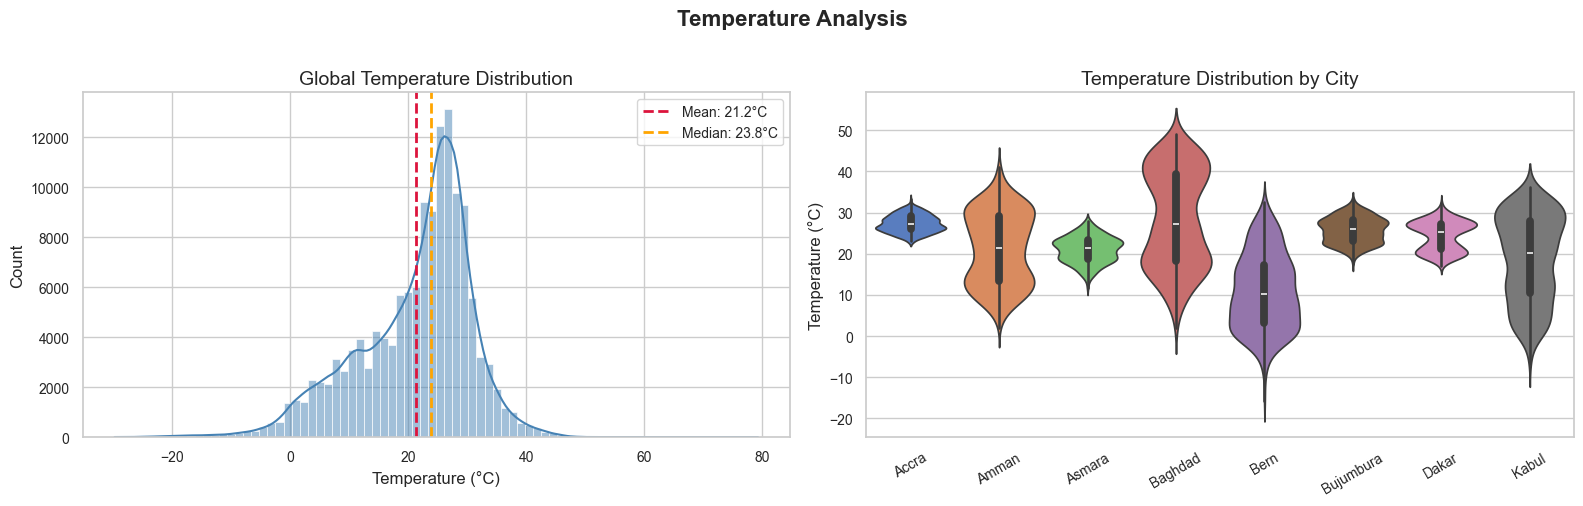

SHAPE= more common temperature at that level.


In [13]:
#4.1 Temperature Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#Global distribution
sns.histplot(df['temperature_celsius'], bins=80, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df['temperature_celsius'].mean(), color='crimson', lw=2, linestyle='--', label=f'Mean: {df["temperature_celsius"].mean():.1f}°C')
axes[0].axvline(df['temperature_celsius'].median(), color='orange', lw=2, linestyle='--', label=f'Median: {df["temperature_celsius"].median():.1f}°C')
axes[0].set_title('Global Temperature Distribution')
axes[0].set_xlabel('Temperature (°C)')
axes[0].legend()

#Per-city violin plot (top 8 cities by row count)
top_cities = df['location_name'].value_counts().nlargest(8).index
city_data = df[df['location_name'].isin(top_cities)]
sns.violinplot(data=city_data, x='location_name', y='temperature_celsius', palette='muted', ax=axes[1])
axes[1].set_title('Temperature Distribution by City')
axes[1].set_xlabel('')
axes[1].set_ylabel('Temperature (°C)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Temperature Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/01_temp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAPE= more common temperature at that level.")


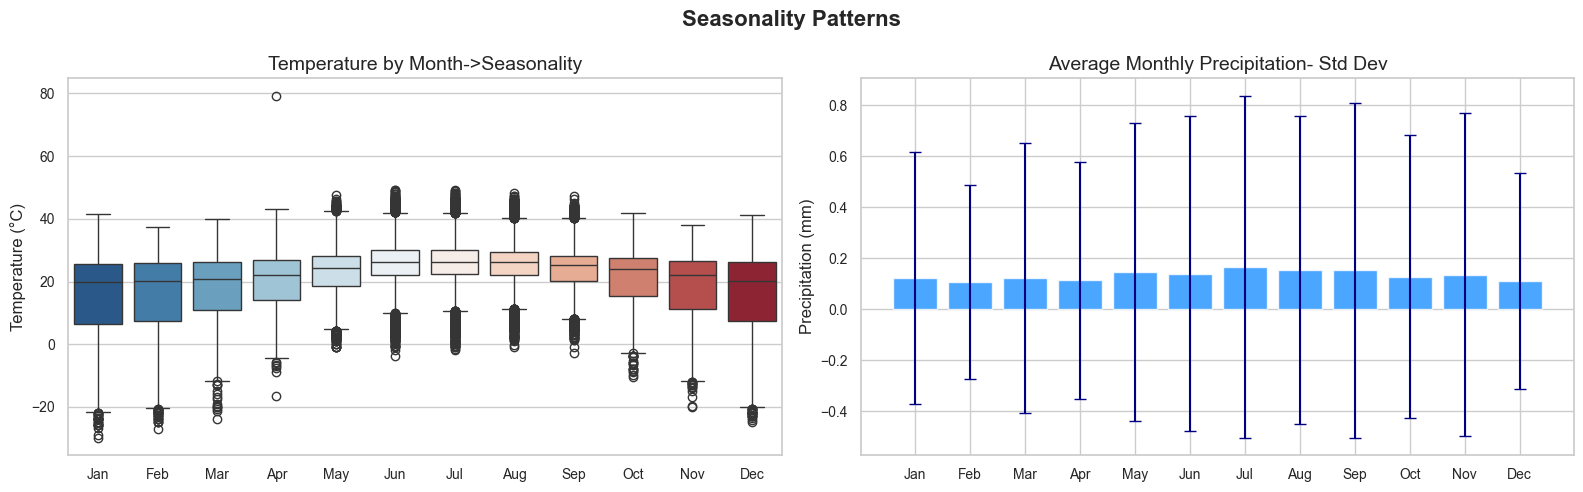

In [14]:
#4.2 Monthly Seasonality
import os; os.makedirs('outputs', exist_ok=True)

fig, axes=plt.subplots(1, 2, figsize=(16, 5))

#Temperature by month — box plot shows median + IQR + outliers
month_labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=df, x='month', y='temperature_celsius', palette='RdBu_r', ax=axes[0])
axes[0].set_xticklabels(month_labels)
axes[0].set_title('Temperature by Month->Seasonality')
axes[0].set_xlabel('')
axes[0].set_ylabel('Temperature (°C)')

#Precipitation by month — bar chart with error bars
precip_monthly=df.groupby('month')['precip_mm'].agg(['mean','std']).reset_index()
axes[1].bar(precip_monthly['month'], precip_monthly['mean'],
            yerr=precip_monthly['std'], color='dodgerblue', alpha=0.8,
            capsize=4, ecolor='navy')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Average Monthly Precipitation- Std Dev')
axes[1].set_xlabel('')
axes[1].set_ylabel('Precipitation (mm)')

plt.suptitle('Seasonality Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


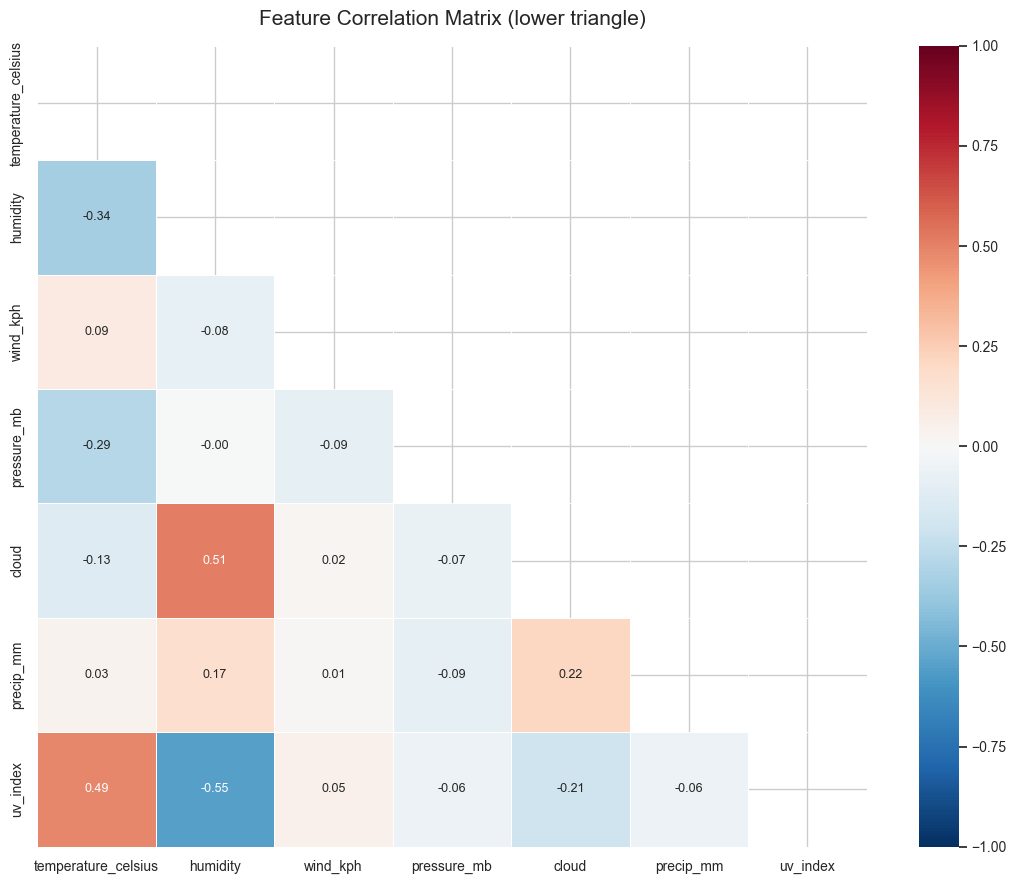

Strong correlations (>0.7 or <-0.7) in red/blue — watch for multicollinearity in regression models.


In [15]:
#4.3 Correlation Heatmap 
corr_cols=['temperature_celsius', 'feelslike_c', 'humidity', 'wind_kph',
             'pressure_mb', 'cloud', 'precip_mm', 'vis_km', 'uv_index']
existing_corr=[c for c in corr_cols if c in df.columns]

corr=df[existing_corr].corr()

fig, ax=plt.subplots(figsize=(11, 9))
mask=np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig('outputs/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Strong correlations (>0.7 or <-0.7) in red/blue — watch for multicollinearity in regression models.")


Reference city: Accra  |  722 daily observations


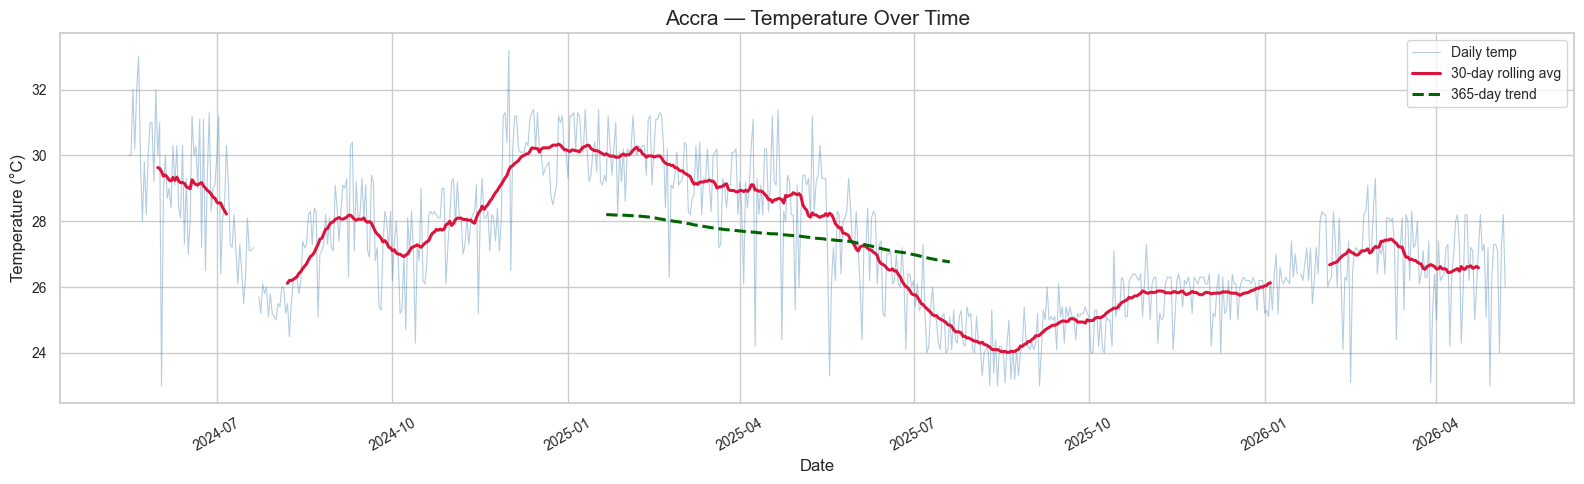

In [16]:
#4.4 Time Series Plot — select a reference city 
#We pick the city with the most data rows as the reference city for modelling.
ref_city=df['location_name'].value_counts().idxmax()
city_df=df[df['location_name'] == ref_city].sort_values('last_updated').copy()
city_ts=city_df.set_index('last_updated')['temperature_celsius']
city_ts=city_ts.resample('D').mean()

print(f"Reference city: {ref_city}  |  {len(city_ts)} daily observations")

fig, ax=plt.subplots(figsize=(16, 5))
ax.plot(city_ts.index, city_ts.values, alpha=0.4, lw=0.8, color='steelblue', label='Daily temp')
#30-day rolling average — smooths noise, reveals trend
roll30=city_ts.rolling(30, center=True).mean()
ax.plot(city_ts.index, roll30.values, lw=2.2, color='crimson', label='30-day rolling avg')
#365-day rolling — long-term trend
roll365=city_ts.rolling(365, center=True).mean()
ax.plot(city_ts.index, roll365.values, lw=2.2, color='darkgreen', linestyle='--', label='365-day trend')

ax.set_title(f'{ref_city} — Temperature Over Time', fontsize=15)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/04_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


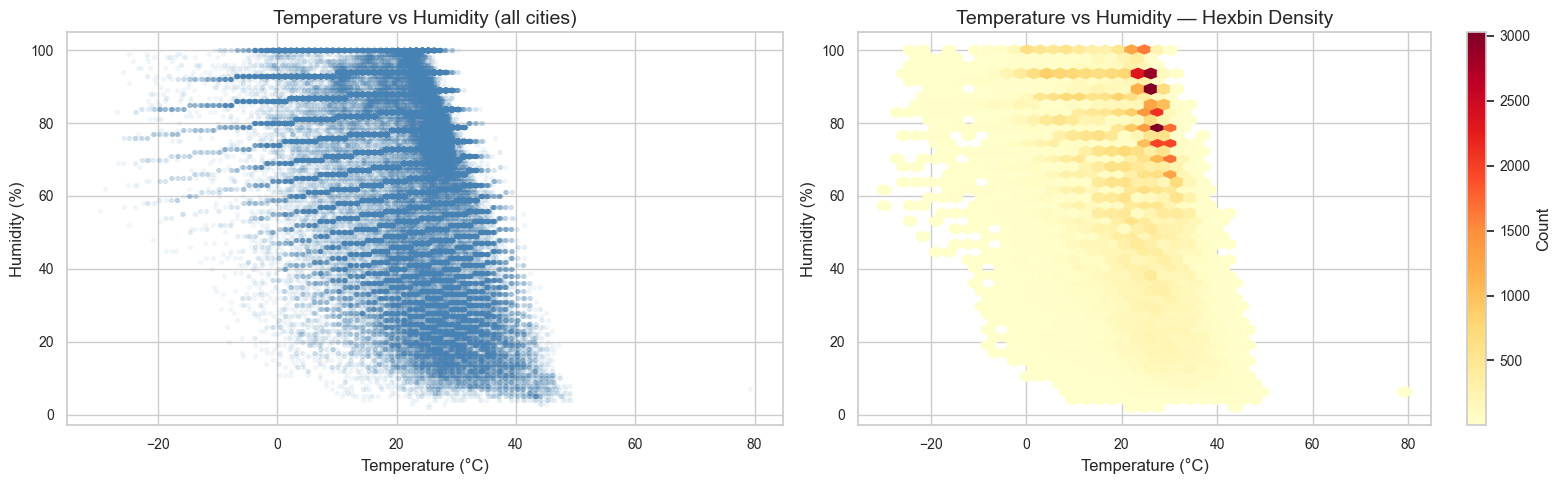

As temperature rises, humidity tends to fall — warmer air can hold more moisture without reaching saturation.


In [17]:
# ── 4.5 Humidity vs Temperature Scatter ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter with density
axes[0].scatter(df['temperature_celsius'], df['humidity'], alpha=0.05, s=8, c='steelblue')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Humidity (%)')
axes[0].set_title('Temperature vs Humidity (all cities)')

# Hexbin for denser view
hb = axes[1].hexbin(df['temperature_celsius'], df['humidity'], gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='Count')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Humidity (%)')
axes[1].set_title('Temperature vs Humidity — Hexbin Density')

plt.tight_layout()
plt.savefig('outputs/05_temp_humidity.png', dpi=150, bbox_inches='tight')
plt.show()
print("As temperature rises, humidity tends to fall — warmer air can hold more moisture without reaching saturation.")


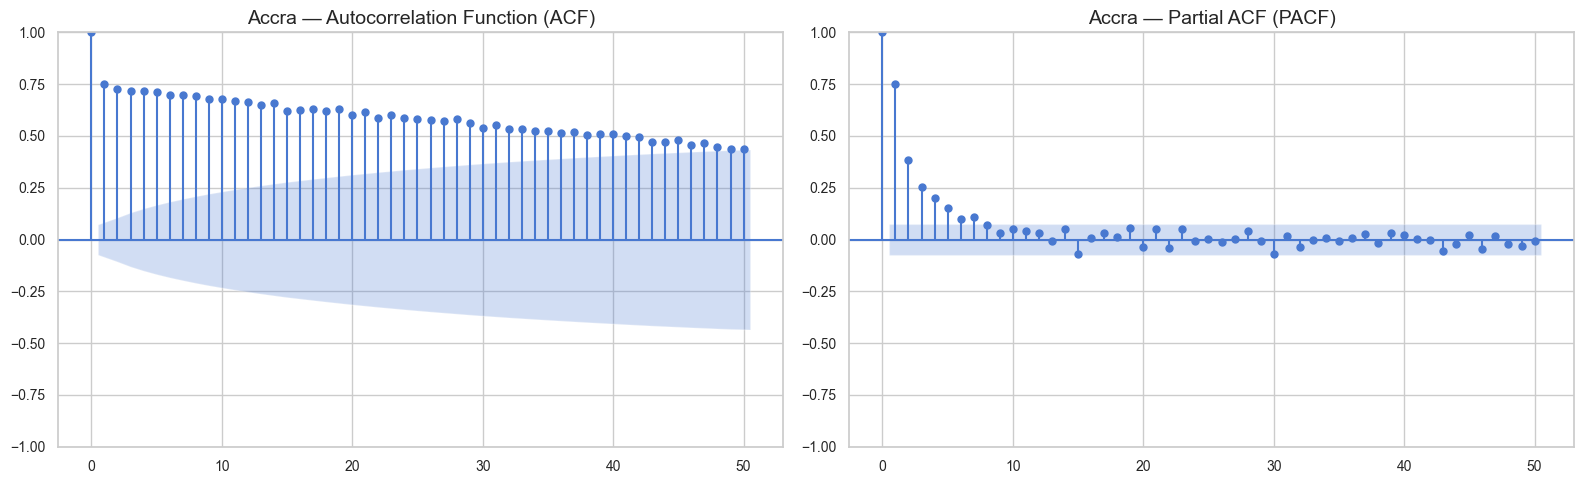

 Significant ACF spikes at lag=7 suggest weekly seasonality. Spikes at lag~365 confirm annual seasonality.


In [76]:
#4.6 ACF and PACF plots


ts_clean=city_ts.dropna()

fig, axes=plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_clean, lags=50, ax=axes[0], alpha=0.05)
axes[0].set_title(f'{ref_city} — Autocorrelation Function (ACF)')
plot_pacf(ts_clean, lags=50, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title(f'{ref_city} — Partial ACF (PACF)')
plt.tight_layout()
plt.savefig('outputs/06_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Significant ACF spikes at lag=7 suggest weekly seasonality. Spikes at lag~365 confirm annual seasonality.")


Section 5 — Time Series Decomposition

**Additive**: `Y = Trend + Seasonal + Residual` -> when seasonal swing is constant  
**Multiplicative**: `Y = Trend × Seasonal × Residual` -> when swing grows with level  
For temperature -> **additive** is almost always correct.


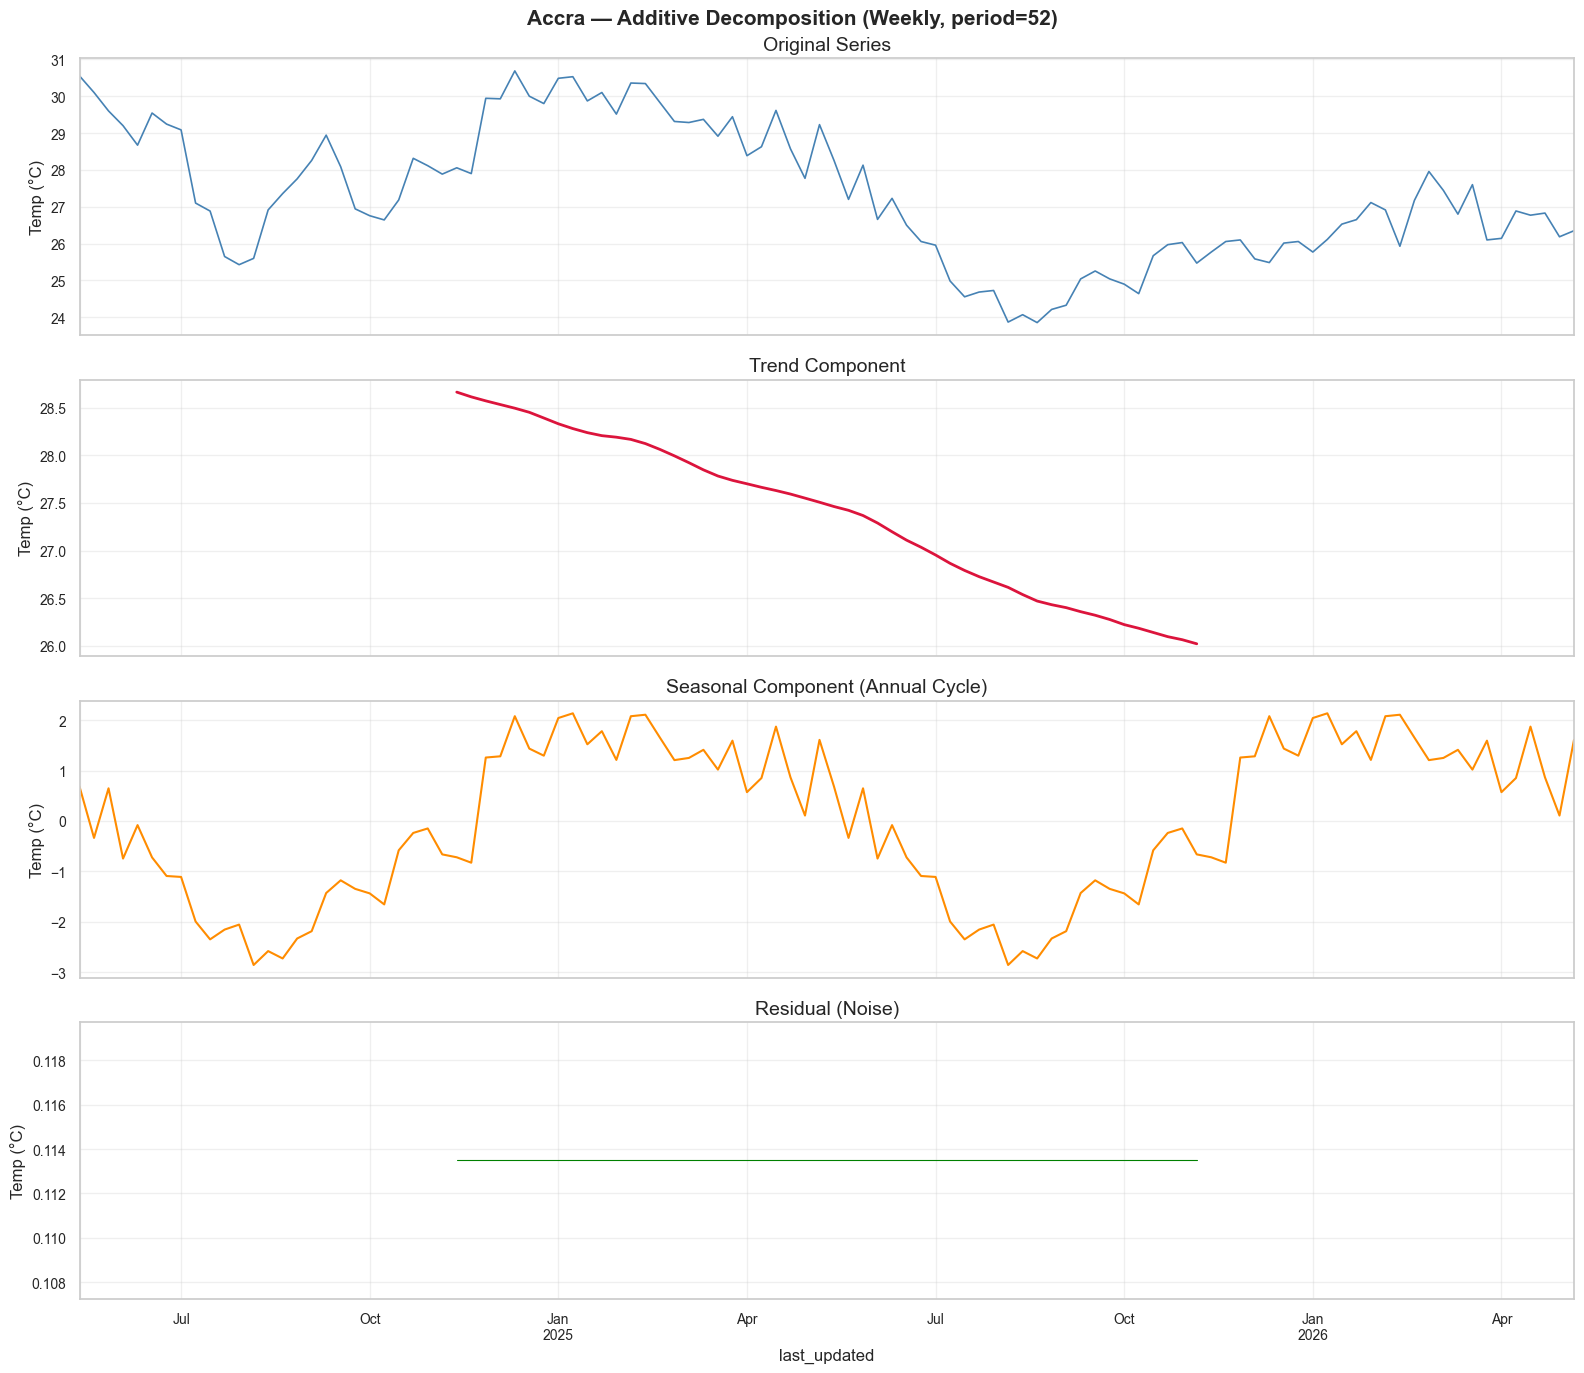

If residuals look random (no pattern), decomposition captured everything important.
 If residuals still show structure → there's a cyclical component not yet captured.


In [19]:
#5.1 Classical Additive Decomposition


city_weekly = city_ts.resample('W').mean().interpolate(method='time')

if len(city_weekly) >= 2 * 52:  #Need at least 2 full seasons
    decomp = seasonal_decompose(city_weekly, model='additive', period=52)

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
    decomp.observed.plot(ax=axes[0], color='steelblue',  lw=1.2); axes[0].set_title('Original Series')
    decomp.trend.plot(  ax=axes[1], color='crimson',    lw=2);   axes[1].set_title('Trend Component')
    decomp.seasonal.plot(ax=axes[2], color='darkorange', lw=1.5); axes[2].set_title('Seasonal Component (Annual Cycle)')
    decomp.resid.plot(  ax=axes[3], color='green',      lw=0.8); axes[3].set_title('Residual (Noise)')

    for ax in axes:
        ax.set_ylabel('Temp (°C)')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'{ref_city} — Additive Decomposition (Weekly, period=52)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/07_decomposition_classical.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("If residuals look random (no pattern), decomposition captured everything important.")
    print(" If residuals still show structure -> there's a cyclical component not yet captured.")
else:
    print(f"Not enough data for decomposition ({len(city_weekly)} weeks). Need ≥104 weeks.")


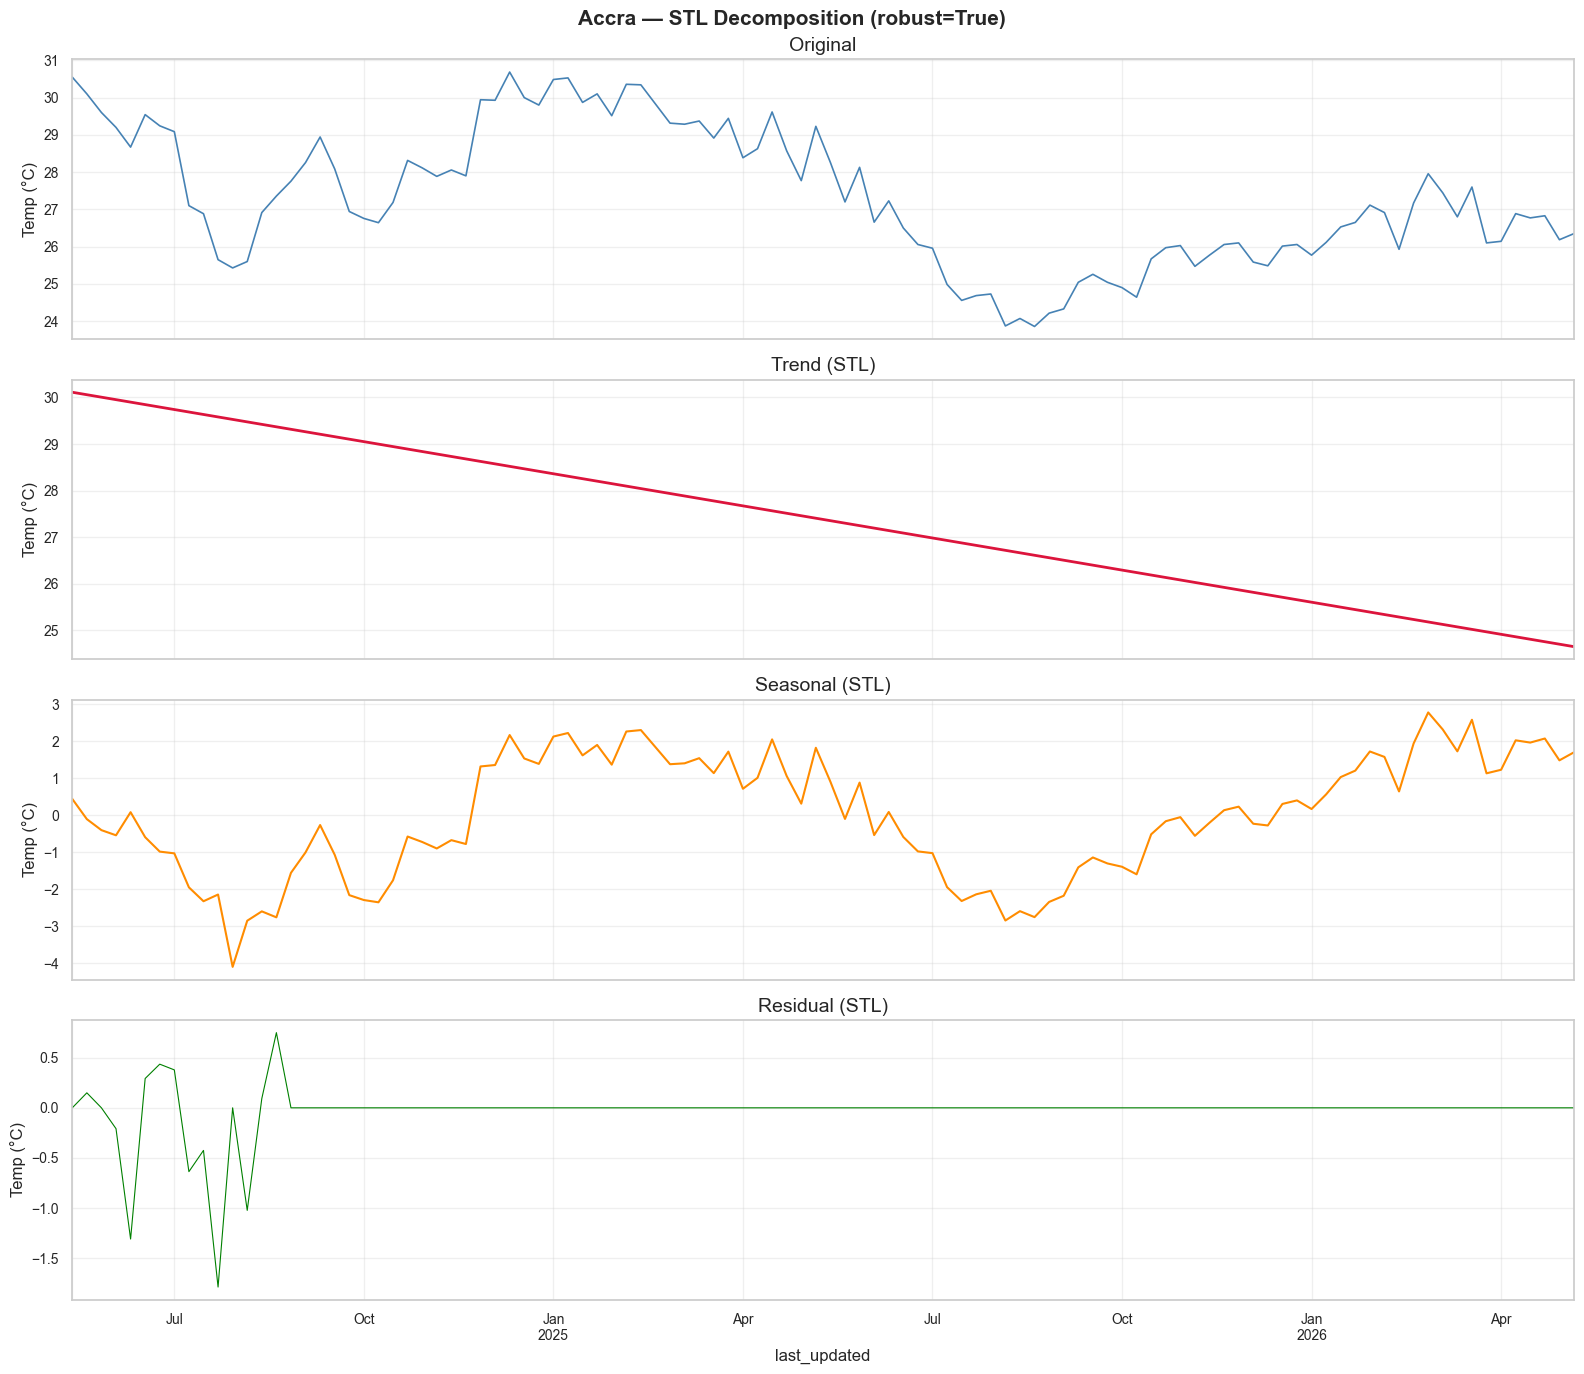

Seasonal Strength: 0.974  (>0.6 = strong seasonality)
Trend Strength:    0.971  (>0.5 = meaningful trend)

Strong seasonality confirmed — seasonal models (SARIMA, Prophet) are appropriate.
Meaningful trend detected — include trend term in forecasting models.


In [20]:
#5.2 STL Decomposition — More Robust
#STL is superior to classical because:
#Handles changing seasonal patterns (seasonal amplitude can vary year-to-year)
#Robust to outliers — a freak storm won't distort the whole seasonal estimate
# Handles missing data better

if len(city_weekly) >= 2 * 52:
    stl = STL(city_weekly, period=52, robust=True)
    stl_result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
    stl_result.observed.plot( ax=axes[0], color='steelblue',   lw=1.2); axes[0].set_title('Original')
    stl_result.trend.plot(    ax=axes[1], color='crimson',     lw=2);   axes[1].set_title('Trend (STL)')
    stl_result.seasonal.plot( ax=axes[2], color='darkorange',  lw=1.5); axes[2].set_title('Seasonal (STL)')
    stl_result.resid.plot(    ax=axes[3], color='green',       lw=0.8); axes[3].set_title('Residual (STL)')

    for ax in axes:
        ax.set_ylabel('Temp (°C)')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'{ref_city} — STL Decomposition (robust=True)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/08_stl_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()

    #Seasonal Strength metric
    var_resid = stl_result.resid.var()
    var_sea_resid = (stl_result.seasonal + stl_result.resid).var()
    seasonal_strength = max(0, 1 - var_resid / var_sea_resid)

    var_trend_resid = (stl_result.trend + stl_result.resid).var()
    trend_strength = max(0, 1 - var_resid / var_trend_resid)

    print(f"Seasonal Strength: {seasonal_strength:.3f}  (>0.6 = strong seasonality)")
    print(f"Trend Strength:    {trend_strength:.3f}  (>0.5 = meaningful trend)")
    print()
    if seasonal_strength > 0.6:
        print("Strong seasonality confirmed — seasonal models (SARIMA, Prophet) are appropriate.")
    if trend_strength > 0.5:
        print("Meaningful trend detected — include trend term in forecasting models.")


In [21]:
#5.3 Stationarity Test (ADF)
#SARIMA requires the series to be stationary (constant mean & variance).
#We use the Augmented Dickey-Fuller test to check.

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"  ADF Statistic:  {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}  {'Stationary' if result[1] < 0.05 else 'Non-stationary — needs differencing'}")
    print(f"  Critical values: {result[4]}")
    return result[1] < 0.05

print(f"── ADF Test: {ref_city} Weekly Temperature ──")
is_stationary = adf_test(city_weekly, ref_city)

if not is_stationary:
    print("\nApplying first differencing (d=1)...")
    city_weekly_diff = city_weekly.diff().dropna()
    print("After differencing:")
    adf_test(city_weekly_diff, f'{ref_city} (differenced)')


── ADF Test: Accra Weekly Temperature ──
  ADF Statistic:  -2.2955
  p-value:        0.1734  Non-stationary — needs differencing
  Critical values: {'1%': np.float64(-3.4954932834550623), '5%': np.float64(-2.8900369024285117), '10%': np.float64(-2.5819706975209726)}

Applying first differencing (d=1)...
After differencing:
  ADF Statistic:  -7.8297
  p-value:        0.0000  Stationary
  Critical values: {'1%': np.float64(-3.4968181663902103), '5%': np.float64(-2.8906107514600103), '10%': np.float64(-2.5822770483285953)}


Section 6 — Forecasting with SARIMA


In [22]:
#Train(80)/Test(20) Split — ALWAYS time-based for time series
#Never shuffle — that leaks future information into training

n=len(city_weekly)
split_idx=int(n * 0.8)
split_date=city_weekly.index[split_idx]

train_sarima=city_weekly[:split_idx]
test_sarima =city_weekly[split_idx:]

print(f"Training set:{len(train_sarima)} weeks ({train_sarima.index[0].date()} -> {train_sarima.index[-1].date()})")
print(f"Test set:{len(test_sarima)} weeks ({test_sarima.index[0].date()} -> {test_sarima.index[-1].date()})")


Training set:83 weeks (2024-05-19 -> 2025-12-14)
Test set:21 weeks (2025-12-21 -> 2026-05-10)


In [23]:
#Seasonal Naïve Baseline
#Before any model, compute the naïve baseline: predict same value as 52 weeks ago.
#If model can't beat this, something is wrong.

naive_pred=test_sarima.copy()
naive_pred.iloc[:]=[train_sarima.iloc[max(0, i - 52)] 
                       for i in range(split_idx, split_idx + len(test_sarima))]

mae_naive=mean_absolute_error(test_sarima.dropna(), naive_pred[:len(test_sarima)].dropna())
rmse_naive=np.sqrt(mean_squared_error(test_sarima.dropna(), naive_pred[:len(test_sarima)].dropna()))
print(f"Baseline Seasonal Naïve — MAE: {mae_naive:.2f}°C | RMSE: {rmse_naive:.2f}°C")
print("This is our minimum bar to beat.")


Baseline Seasonal Naïve — MAE: 2.86°C | RMSE: 3.04°C
This is our minimum bar to beat.


In [24]:
#Fit SARIMA(1,1,1)(1,1,1,52)
#For production use, run auto_arima (pmdarima) to search optimally.

print("Fitting SARIMA model")
sarima_model=SARIMAX(
    train_sarima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result=sarima_model.fit(disp=False)
print(sarima_result.summary().tables[0])


Fitting SARIMA model
                                     SARIMAX Results                                      
Dep. Variable:                temperature_celsius   No. Observations:                   83
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                   0.000
Date:                            Fri, 08 May 2026   AIC                             10.000
Time:                                    02:20:21   BIC                                nan
Sample:                                05-19-2024   HQIC                               nan
                                     - 12-14-2025                                         
Covariance Type:                              opg                                         


SARIMA — MAE: 9.48°C | RMSE: 14.62°C | R²: -628.305
Improvement over baseline: -231.5%


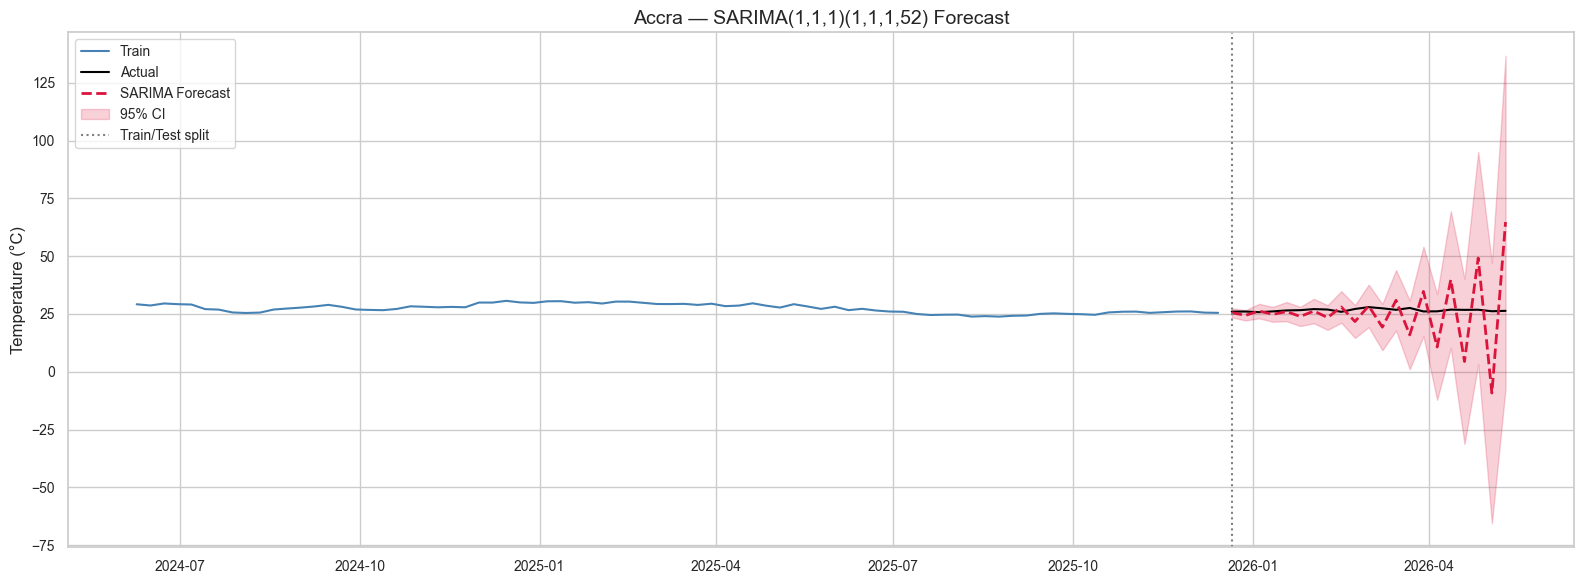

In [25]:
#SARIMA Forecast
forecast_obj=sarima_result.get_forecast(steps=len(test_sarima))
sarima_pred=forecast_obj.predicted_mean
conf_int=forecast_obj.conf_int(alpha=0.05)

#Evaluation
sarima_pred_aligned=sarima_pred.values[:len(test_sarima)]
test_vals=test_sarima.values[:len(sarima_pred_aligned)]

mae_sarima =mean_absolute_error(test_vals, sarima_pred_aligned)
rmse_sarima=np.sqrt(mean_squared_error(test_vals, sarima_pred_aligned))
r2_sarima=r2_score(test_vals, sarima_pred_aligned)

print(f"SARIMA — MAE: {mae_sarima:.2f}°C | RMSE: {rmse_sarima:.2f}°C | R²: {r2_sarima:.3f}")
print(f"Improvement over baseline: {(mae_naive - mae_sarima)/mae_naive*100:.1f}%")

#Plot
fig, ax=plt.subplots(figsize=(16, 6))
ax.plot(train_sarima.index[-80:], train_sarima.values[-80:], color='steelblue', lw=1.5, label='Train')
ax.plot(test_sarima.index,  test_sarima.values,  color='black',     lw=1.5, label='Actual')
ax.plot(sarima_pred.index,  sarima_pred.values,  color='crimson',   lw=2,   label='SARIMA Forecast', linestyle='--')
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                alpha=0.2, color='crimson', label='95% CI')
ax.axvline(split_date, color='grey', lw=1.5, linestyle=':', label='Train/Test split')
ax.set_title(f'{ref_city} — SARIMA(1,1,1)(1,1,1,52) Forecast', fontsize=14)
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/09_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


🔮 Section 7 — Forecasting with Facebook Prophet

Prophet was designed by Meta for business forecasting. It excels at data with  
**strong seasonal patterns and occasional outliers or missing data**.  
It decomposes into trend + yearly + weekly components automatically.  
>
Key parameter: `changepoint_prior_scale` — how flexible the trend is.  
Too high -> overfits sudden changes. Too low -> misses real trend shifts.  
Default 0.05 is usually a good start.


In [26]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [27]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print("Prophet imported successfully.")
except ImportError:
    print("Prophet not installed. Run: pip install prophet")
    print("Skipping Prophet section — will still show all other models.")
    PROPHET_AVAILABLE = False


Prophet imported successfully.


02:21:26 - cmdstanpy - INFO - Chain [1] start processing
02:21:26 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAE: 1.21°C | RMSE: 1.43°C | R²: -0.542


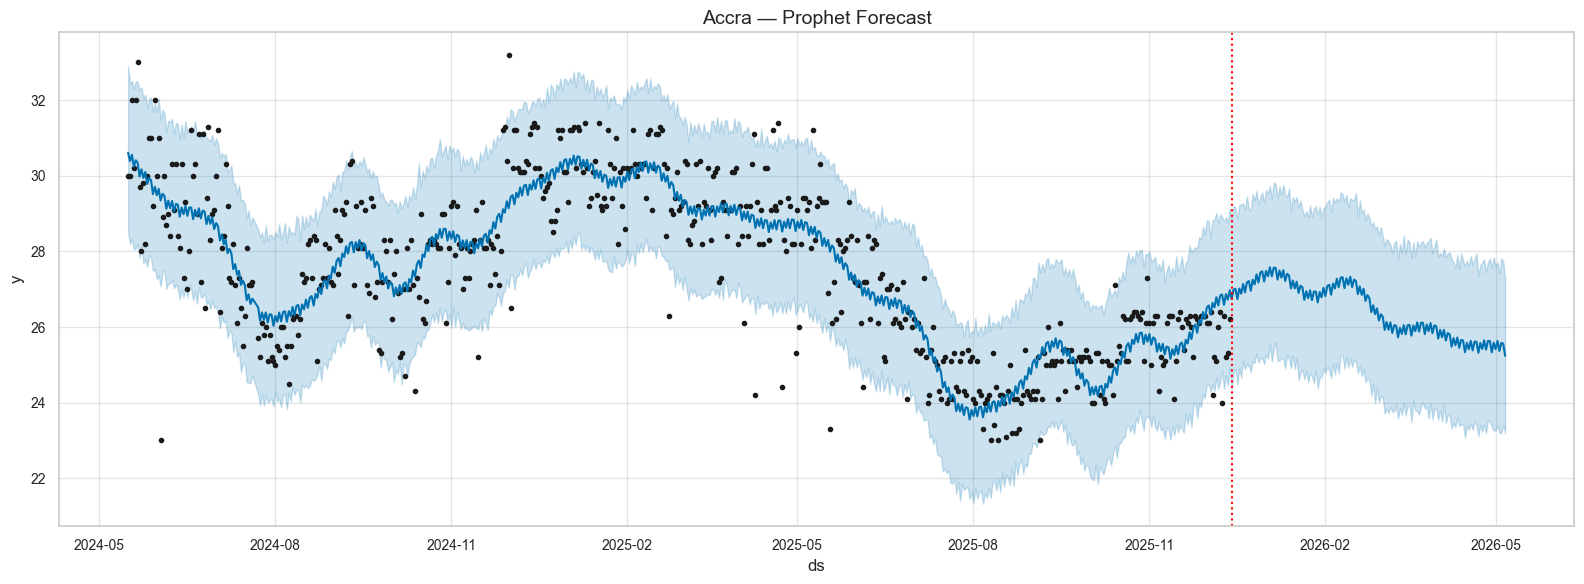

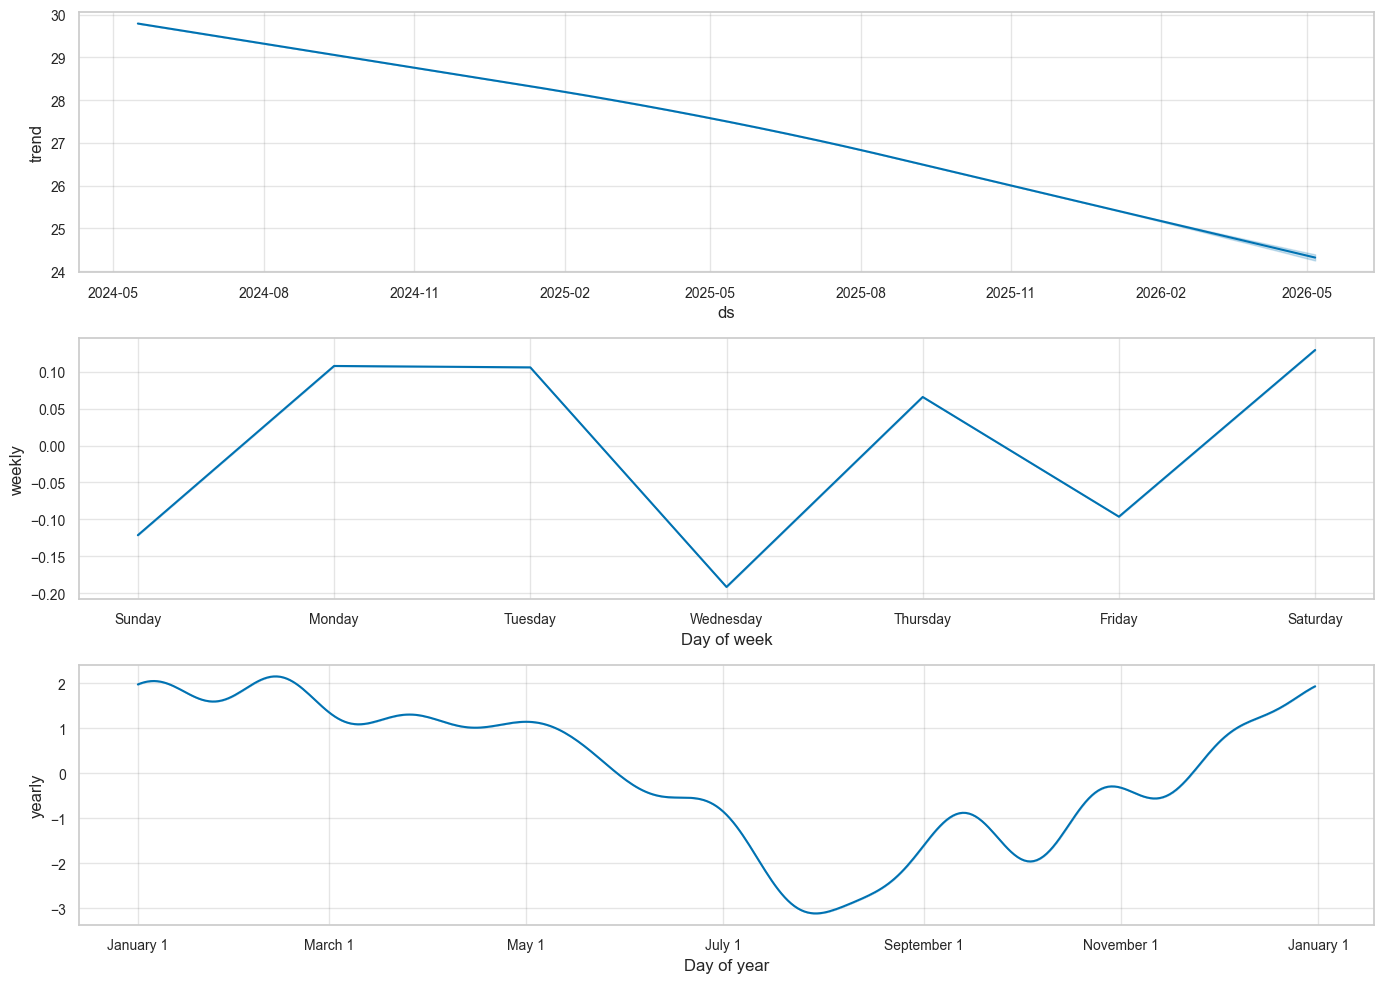

The components plot shows how much each factor (trend, week, year) contributes.


In [29]:
if PROPHET_AVAILABLE:
    #Prophet requires columns named 'ds' (datestamp) and 'y' (value)
    prophet_df = city_ts.reset_index()
    prophet_df.columns = ['ds', 'y']
    prophet_df = prophet_df.dropna()

    #Same 80/20 time split
    split_date_daily = city_ts.index[int(len(city_ts) * 0.8)]
    prophet_train = prophet_df[prophet_df['ds'] < split_date_daily]
    prophet_test  = prophet_df[prophet_df['ds'] >= split_date_daily]

    model_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,   #trend flexibility
        seasonality_mode='additive',
        interval_width=0.95
    )
    model_prophet.fit(prophet_train)

    #Predict on test period
    future = model_prophet.make_future_dataframe(periods=len(prophet_test))
    forecast = model_prophet.predict(future)

    prophet_pred = forecast.set_index('ds')['yhat'].loc[split_date_daily:]
    actual_aligned = prophet_test.set_index('ds')['y']
    common_idx = prophet_pred.index.intersection(actual_aligned.index)

    mae_prophet  = mean_absolute_error(actual_aligned[common_idx], prophet_pred[common_idx])
    rmse_prophet = np.sqrt(mean_squared_error(actual_aligned[common_idx], prophet_pred[common_idx]))
    r2_prophet   = r2_score(actual_aligned[common_idx], prophet_pred[common_idx])

    print(f"Prophet — MAE: {mae_prophet:.2f}°C | RMSE: {rmse_prophet:.2f}°C | R²: {r2_prophet:.3f}")

    #Plot forecast
    fig = model_prophet.plot(forecast, figsize=(16, 6))
    plt.axvline(pd.Timestamp(split_date_daily), color='red', lw=1.5, linestyle=':', label='Train/Test split')
    plt.title(f'{ref_city} — Prophet Forecast', fontsize=14)
    plt.tight_layout()
    plt.savefig('outputs/10_prophet_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()

    #Component breakdown
    fig2 = model_prophet.plot_components(forecast, figsize=(14, 10))
    plt.tight_layout()
    plt.savefig('outputs/11_prophet_components.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("The components plot shows how much each factor (trend, week, year) contributes.")
else:
    mae_prophet = rmse_prophet = r2_prophet = None
    print("Skipping Prophet (not installed).")


Section 8 — ML-Based Forecasting (XGBoost & LightGBM)

 ML models treat forecasting as a **supervised regression problem**: given a row of  
 features (yesterday's temp, last week's temp, month of year, etc.), predict today's temp.  





In [30]:
#8.1 Feature Engineering for ML
#We work with the reference city's daily series.

ml_df=city_ts.to_frame(name='temp_c').copy()
ml_df['day_of_year']=ml_df.index.dayofyear
ml_df['month']      =ml_df.index.month
ml_df['year']       =ml_df.index.year
ml_df['week']       =ml_df.index.isocalendar().week.astype(int)

#Cyclical time features
ml_df['sin_doy']=np.sin(2 * np.pi * ml_df['day_of_year'] / 365)
ml_df['cos_doy']=np.cos(2 * np.pi * ml_df['day_of_year'] / 365)
ml_df['sin_month']=np.sin(2 * np.pi * ml_df['month'] / 12)
ml_df['cos_month']=np.cos(2 * np.pi * ml_df['month'] / 12)

#Lag features — past observations as predictors
for lag in [1, 2, 3, 7, 14, 30, 90, 180, 365]:
    ml_df[f'lag_{lag}']=ml_df['temp_c'].shift(lag)

#Rolling statistics — smoothed views of the recent past
for window in [7, 14, 30, 90]:
    ml_df[f'roll_mean_{window}']=ml_df['temp_c'].shift(1).rolling(window).mean()
    ml_df[f'roll_std_{window}'] =ml_df['temp_c'].shift(1).rolling(window).std()
    ml_df[f'roll_max_{window}'] =ml_df['temp_c'].shift(1).rolling(window).max()
    ml_df[f'roll_min_{window}'] =ml_df['temp_c'].shift(1).rolling(window).min()

#Diff features — how much did temp change recently?
ml_df['diff_1'] =ml_df['temp_c'].diff(1)
ml_df['diff_7'] =ml_df['temp_c'].diff(7)
ml_df['diff_365']= ml_df['temp_c'].diff(365)

ml_df=ml_df.dropna()
print(f"ML feature matrix: {ml_df.shape[0]} rows × {ml_df.shape[1]} columns")
print(f"Features: {[c for c in ml_df.columns if c != 'temp_c']}")


ML feature matrix: 264 rows × 37 columns
Features: ['day_of_year', 'month', 'year', 'week', 'sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'lag_90', 'lag_180', 'lag_365', 'roll_mean_7', 'roll_std_7', 'roll_max_7', 'roll_min_7', 'roll_mean_14', 'roll_std_14', 'roll_max_14', 'roll_min_14', 'roll_mean_30', 'roll_std_30', 'roll_max_30', 'roll_min_30', 'roll_mean_90', 'roll_std_90', 'roll_max_90', 'roll_min_90', 'diff_1', 'diff_7', 'diff_365']


In [32]:
#8.2 Train / Test Split
feature_cols=[c for c in ml_df.columns if c != 'temp_c']
X=ml_df[feature_cols]
y=ml_df['temp_c']

split_idx_ml=int(len(ml_df) * 0.8)
X_train, X_test=X.iloc[:split_idx_ml], X.iloc[split_idx_ml:]
y_train, y_test=y.iloc[:split_idx_ml], y.iloc[split_idx_ml:]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")


Train: 211 rows | Test: 53 rows


In [30]:
# ── 8.3 XGBoost Model ────────────────────────────────────────────────────────
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb   = r2_score(y_test, xgb_pred)
print(f"XGBoost — MAE: {mae_xgb:.2f}°C | RMSE: {rmse_xgb:.2f}°C | R²: {r2_xgb:.3f}")


Training XGBoost...


XGBoost — MAE: 4.86°C | RMSE: 5.97°C | R²: -1.144


In [33]:
#8.4 LightGBM Model
print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.04,
    max_depth=6,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbose=-1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

lgb_pred = lgb_model.predict(X_test)
mae_lgb  = mean_absolute_error(y_test, lgb_pred)
rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_pred))
r2_lgb   = r2_score(y_test, lgb_pred)
print(f"LightGBM — MAE: {mae_lgb:.2f}°C | RMSE: {rmse_lgb:.2f}°C | R²: {r2_lgb:.3f}")


Training LightGBM...
LightGBM — MAE: 0.31°C | RMSE: 0.54°C | R²: 0.654


In [44]:
#8.5 Random Forest 
print("Training Random Forest...")
rf_model=RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    n_jobs=-1, random_state=SEED
)
rf_model.fit(X_train, y_train)

rf_pred=rf_model.predict(X_test)
mae_rf =mean_absolute_error(y_test, rf_pred)
rmse_rf=np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf  =r2_score(y_test, rf_pred)
print(f"Random Forest — MAE: {mae_rf:.2f}°C | RMSE: {rmse_rf:.2f}°C | R²: {r2_rf:.3f}")


Training Random Forest...
Random Forest — MAE: 0.44°C | RMSE: 0.71°C | R²: 0.405


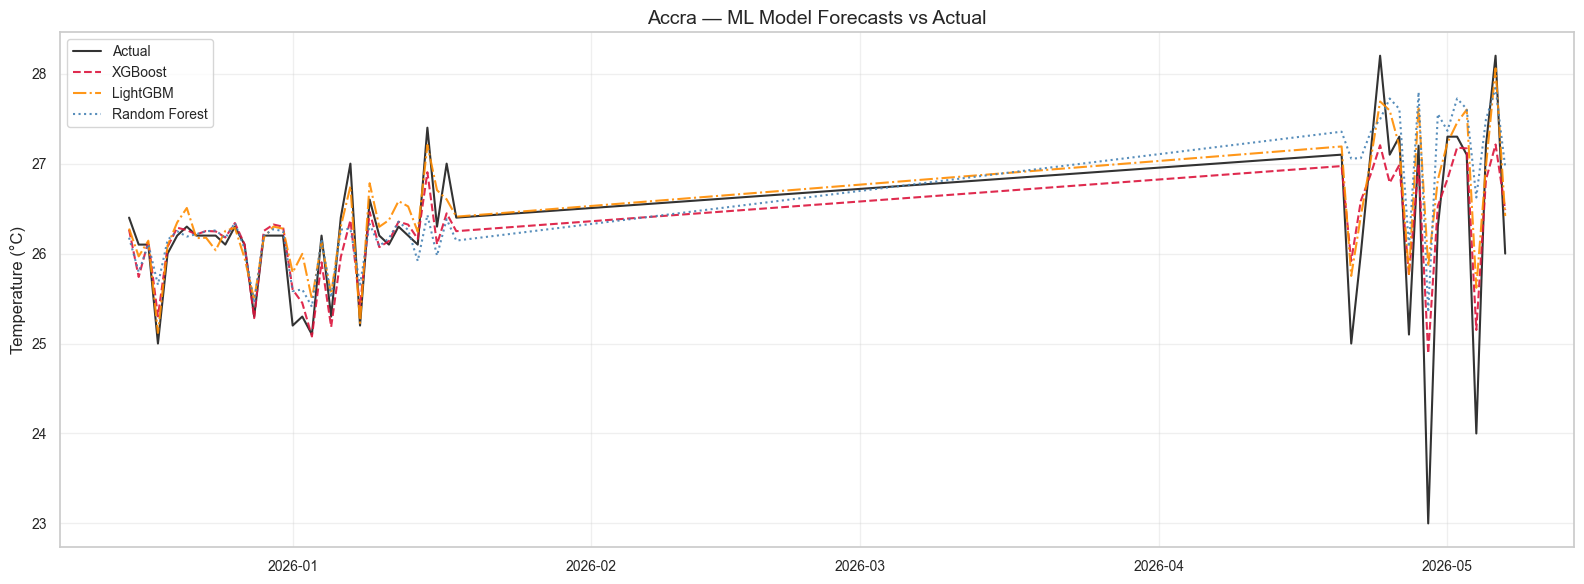

In [52]:
#8.6 Forecast Plot — XGBoost
if 'xgb_model' not in globals():
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_model.fit(X_train, y_train)

if 'xgb_pred' not in globals() or xgb_pred is None:
    xgb_pred = xgb_model.predict(X_test)
if 'lgb_pred' not in globals() or lgb_pred is None:
    lgb_pred = lgb_model.predict(X_test)
if 'rf_pred' not in globals() or rf_pred is None:
    rf_pred = rf_model.predict(X_test)

fig, ax = plt.subplots(figsize=(16, 6))
plot_dates = ml_df.index[split_idx_ml:]
ax.plot(plot_dates, y_test.values, color='black', lw=1.5, label='Actual', alpha=0.8)
ax.plot(plot_dates, xgb_pred, color='crimson', lw=1.5, label='XGBoost', linestyle='--', alpha=0.9)
ax.plot(plot_dates, lgb_pred, color='darkorange', lw=1.5, label='LightGBM', linestyle='-.', alpha=0.9)
ax.plot(plot_dates, rf_pred, color='steelblue', lw=1.5, label='Random Forest', linestyle=':', alpha=0.9)
ax.set_title(f'{ref_city} — ML Model Forecasts vs Actual', fontsize=14)
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/12_ml_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

Section 9 — Ensemble Modeling

We implement three ensemble strategies:  
**Simple average** — treat all models equally  
**Weighted average** — weight by inverse validation MAE  
**Stacking** — train a meta-model to learn optimal weights  


In [53]:
#9.1 Simple Average Ensemble 
if xgb_pred is None:
    xgb_pred = xgb_model.predict(X_test)

ensemble_simple = (xgb_pred + lgb_pred + rf_pred) / 3

mae_ens_simple =mean_absolute_error(y_test, ensemble_simple)
rmse_ens_simple=np.sqrt(mean_squared_error(y_test, ensemble_simple))
r2_ens_simple  =r2_score(y_test, ensemble_simple)
print(f"Simple Ensemble — MAE: {mae_ens_simple:.2f}°C | RMSE: {rmse_ens_simple:.2f}°C | R²: {r2_ens_simple:.3f}")


Simple Ensemble — MAE: 0.31°C | RMSE: 0.54°C | R²: 0.662


In [60]:
#9.2 Weighted Average — inverse MAE weights 
#Lower MAE -> higher weight. We normalise so weights sum to 1.

if 'xgb_pred' not in globals() or xgb_pred is None:
    xgb_pred = xgb_model.predict(X_test)
if 'lgb_pred' not in globals() or lgb_pred is None:
    lgb_pred = lgb_model.predict(X_test)
if 'rf_pred' not in globals() or rf_pred is None:
    rf_pred = rf_model.predict(X_test)

if 'mae_xgb' not in globals():
    mae_xgb = mean_absolute_error(y_test, xgb_pred)
if 'mae_lgb' not in globals():
    mae_lgb = mean_absolute_error(y_test, lgb_pred)
if 'mae_rf' not in globals():
    mae_rf = mean_absolute_error(y_test, rf_pred)

maes = np.array([mae_xgb, mae_lgb, mae_rf])
inv_mae = 1 / maes
weights = inv_mae / inv_mae.sum()
print(f"Weights — XGBoost: {weights[0]:.3f} | LightGBM: {weights[1]:.3f} | RF: {weights[2]:.3f}")

ensemble_weighted = weights[0] * xgb_pred + weights[1] * lgb_pred + weights[2] * rf_pred
mae_ens_w  = mean_absolute_error(y_test, ensemble_weighted)
rmse_ens_w = np.sqrt(mean_squared_error(y_test, ensemble_weighted))
r2_ens_w   = r2_score(y_test, ensemble_weighted)
print(f"Weighted Ensemble — MAE: {mae_ens_w:.2f}°C | RMSE: {rmse_ens_w:.2f}°C | R²: {r2_ens_w:.3f}")

Weights — XGBoost: 0.378 | LightGBM: 0.363 | RF: 0.259
Weighted Ensemble — MAE: 0.30°C | RMSE: 0.52°C | R²: 0.682


In [61]:
# ── 9.3 Stacking Meta-Model ──────────────────────────────────────────────────
# Step 1: Stack base model predictions as features for the meta-model
# Step 2: Ridge regression learns optimal combination
# NOTE: If the kernel was restarted, rebuild missing models/predictions first.

if 'xgb_model' not in globals():
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=600,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        verbosity=0,
    )
    xgb_model.fit(X_train, y_train)

if 'lgb_model' not in globals():
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.04,
        max_depth=6,
        num_leaves=40,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        verbose=-1,
    )
    lgb_model.fit(X_train, y_train)

if 'rf_model' not in globals():
    rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED,
    )
    rf_model.fit(X_train, y_train)

if 'xgb_pred' not in globals() or xgb_pred is None:
    xgb_pred = xgb_model.predict(X_test)
if 'lgb_pred' not in globals() or lgb_pred is None:
    lgb_pred = lgb_model.predict(X_test)
if 'rf_pred' not in globals() or rf_pred is None:
    rf_pred = rf_model.predict(X_test)

stack_train = np.column_stack([
    xgb_model.predict(X_train),
    lgb_model.predict(X_train),
    rf_model.predict(X_train),
])
stack_test = np.column_stack([xgb_pred, lgb_pred, rf_pred])

meta_model = Ridge(alpha=1.0)
meta_model.fit(stack_train, y_train)
ensemble_stack = meta_model.predict(stack_test)

mae_stack = mean_absolute_error(y_test, ensemble_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, ensemble_stack))
r2_stack = r2_score(y_test, ensemble_stack)
print(f"Stacking Ensemble — MAE: {mae_stack:.2f}°C | RMSE: {rmse_stack:.2f}°C | R²: {r2_stack:.3f}")
print(f"Meta-model weights: XGB={meta_model.coef_[0]:.3f}, LGB={meta_model.coef_[1]:.3f}, RF={meta_model.coef_[2]:.3f}")

Stacking Ensemble — MAE: 0.27°C | RMSE: 0.46°C | R²: 0.749
Meta-model weights: XGB=0.695, LGB=0.321, RF=-0.016


Section 10 — Anomaly Detection

ANOMALY data points — heatwaves, cold snaps, floods.  
 Two complementary approaches:  
 - **Z-score (statistical)**: fast, interpretable, but assumes normality  
 - **Isolation Forest (ML)**: works on multiple features at once, finds complex outliers  


In [63]:
#10.1 Seasonal Z-Score Method
#Key insight: a 30°C day is normal in June but anomalous in December.
#We compute Z-scores WITHIN each (city, month) group to account for seasonality.

df_anom=df.copy()
df_anom['temp_monthly_mean']=df_anom.groupby(['location_name', 'month'])['temperature_celsius'].transform('mean')
df_anom['temp_monthly_std']=df_anom.groupby(['location_name', 'month'])['temperature_celsius'].transform('std')
df_anom['temp_zscore']=((df_anom['temperature_celsius'] - df_anom['temp_monthly_mean']) /
                                 df_anom['temp_monthly_std'].replace(0, np.nan))
df_anom['anomaly_zscore']=df_anom['temp_zscore'].abs() > 3

n_anom=df_anom['anomaly_zscore'].sum()
print(f"Z-score anomalies detected: {n_anom:,} ({n_anom/len(df_anom)*100:.2f}% of data)")
print("\nTop 10 temperature anomalies:")
top_anom=(df_anom[df_anom['anomaly_zscore']]
            .nlargest(10, 'temp_zscore')
            [['location_name', 'country', 'last_updated', 'temperature_celsius', 'temp_zscore']])
print(top_anom.to_string(index=False))


Z-score anomalies detected: 350 (0.25% of data)

Top 10 temperature anomalies:
 location_name      country        last_updated  temperature_celsius  temp_zscore
          Suva Fiji Islands 2026-04-24 18:30:00                 79.3     7.500764
    Nouakchott   Mauritania 2024-08-29 12:00:00                 35.3     4.631560
        Muscat         Oman 2025-09-29 11:45:00                 42.3     4.383037
Vestmannaeyjar      Iceland 2025-07-14 09:00:00                 17.2     4.349754
       Tallinn      Estonia 2024-06-28 16:15:00                 32.3     4.079229
   San Ignacio   Costa Rica 2024-11-17 02:45:00                 18.1     4.060287
   Addis Ababa     Ethiopia 2024-09-12 15:15:00                 29.4     4.010365
        Moroni      Comoros 2024-07-17 15:45:00                 29.3     4.000760
        Moroni      Comoros 2025-07-31 11:30:00                 29.3     4.000760
         Rabat      Morocco 2024-07-19 13:30:00                 32.1     3.982923


In [64]:
#10.2 Isolation Forest — Multivariate
#Isolation Forest detects anomalies by randomly partitioning the feature space.
#Anomalies are isolated in fewer splits (shorter path length)=more anomalous.

iso_features=['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']
if 'precip_mm' in df.columns: iso_features.append('precip_mm')
existing_iso=[c for c in iso_features if c in df.columns]

iso_data=df[existing_iso].dropna()
iso_forest=IsolationForest(
    contamination=0.02,  #expect ~2% anomalies
    n_estimators=200,
    random_state=SEED
)
iso_labels=iso_forest.fit_predict(iso_data)
iso_scores=iso_forest.decision_function(iso_data)

df_anom_iso=iso_data.copy()
df_anom_iso['anomaly_if']   =iso_labels == -1
df_anom_iso['anomaly_score']=iso_scores

n_iso=df_anom_iso['anomaly_if'].sum()
print(f"Isolation Forest anomalies: {n_iso:,} ({n_iso/len(df_anom_iso)*100:.2f}% of data)")


Isolation Forest anomalies: 2,799 (2.00% of data)


KeyError: 'temp_c'

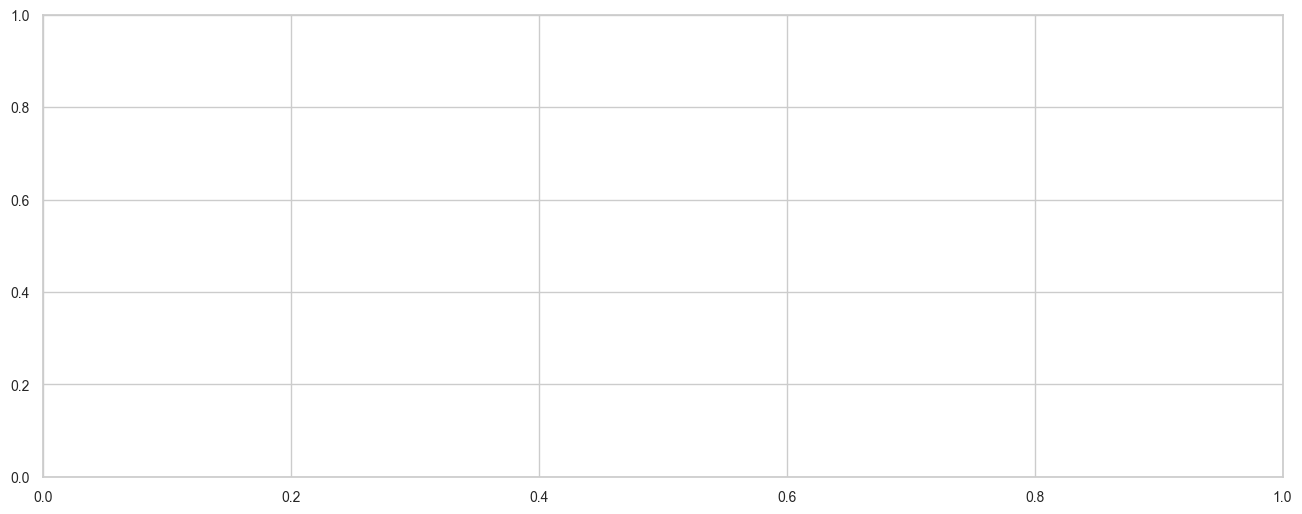

In [65]:
#10.3 Visualise Anomalies on Time Series
city_anom=df_anom[df_anom['location_name'] == ref_city].sort_values('last_updated')

fig, ax=plt.subplots(figsize=(16, 6))
ax.plot(city_anom['last_updated'], city_anom['temp_c'],
        color='steelblue', lw=1.2, alpha=0.7, label='Temperature')

#Highlight Z-score anomalies
anom_pts=city_anom[city_anom['anomaly_zscore']]
ax.scatter(anom_pts['last_updated'], anom_pts['temp_c'],
           color='crimson', s=60, zorder=5, label=f'Z-score anomalies (n={len(anom_pts)})')

ax.set_title(f'{ref_city} — Temperature Anomaly Detection (Z-score |z|>3)', fontsize=14)
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/13_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()


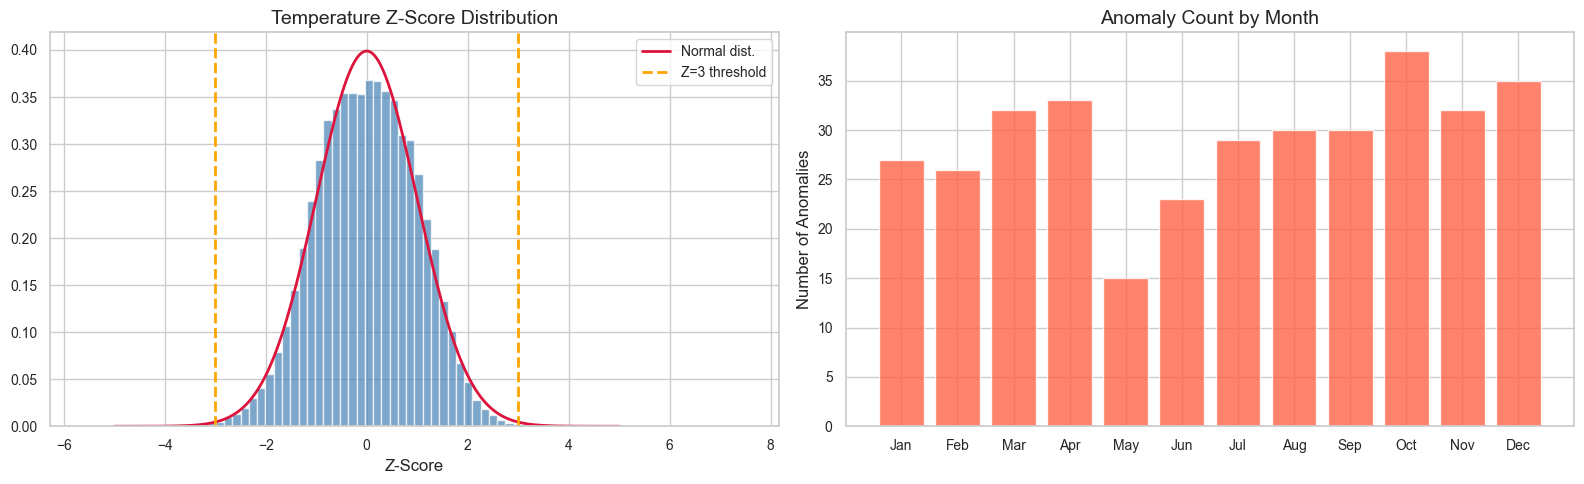

In [66]:
#10.4 Anomaly Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#Z-score distribution
axes[0].hist(df_anom['temp_zscore'].dropna(), bins=80, color='steelblue', alpha=0.7, density=True)
x = np.linspace(-5, 5, 200)
axes[0].plot(x, stats.norm.pdf(x), color='crimson', lw=2, label='Normal dist.')
axes[0].axvline(3,  color='orange', lw=2, linestyle='--', label='Z=3 threshold')
axes[0].axvline(-3, color='orange', lw=2, linestyle='--')
axes[0].set_title('Temperature Z-Score Distribution')
axes[0].set_xlabel('Z-Score')
axes[0].legend()

#Anomaly count by month
anom_monthly = df_anom.groupby('month')['anomaly_zscore'].sum()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(range(1, 13), anom_monthly.values, color='tomato', alpha=0.8)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Anomaly Count by Month')
axes[1].set_ylabel('Number of Anomalies')

plt.tight_layout()
plt.savefig('outputs/14_anomaly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Section 11 — Spatial & Climate Analysis

In [68]:
#11.1 Country-level Aggregation
country_agg = df.groupby('country').agg(
    avg_temp    =('temperature_celsius',   'mean'),
    avg_humidity=('humidity', 'mean'),
    avg_precip  =('precip_mm','mean'),
    avg_wind    =('wind_kph', 'mean'),
    n_records   =('temperature_celsius',   'count')
).reset_index().round(2)

print(f"Countries aggregated: {len(country_agg)}")
print("\nTop 10 hottest countries:")
print(country_agg.nlargest(10, 'avg_temp')[['country','avg_temp','avg_humidity']].to_string(index=False))


Countries aggregated: 211

Top 10 hottest countries:
             country  avg_temp  avg_humidity
       Saudi Arabien     45.00          7.00
            Marrocos     40.30         14.00
        Turkménistan     37.80         11.00
              Турция     34.00         44.00
United Arab Emirates     32.09         44.18
               Qatar     32.06         41.59
            Cambodia     31.79         60.93
                Oman     31.47         51.30
            Djibouti     31.30         56.01
                Inde     31.20         71.00


In [77]:
#11.2 Choropleth — Average Temperature
fig=px.choropleth(
    country_agg,
    locations='country',
    locationmode='country names',
    color='avg_temp',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=15,
    title='Average Temperature by Country (°C)',
    labels={'avg_temp': 'Avg Temp (°C)'},
    hover_data=['avg_humidity', 'avg_precip', 'n_records']
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    height=500, margin={'r':0,'t':60,'l':0,'b':0}
)
fig.write_html('outputs/15_choropleth_temp.html')
fig.show()
print(" Saved interactive map to outputs/15_choropleth_temp.html")


 Saved interactive map to outputs/15_choropleth_temp.html


In [43]:
# ── 11.3 Choropleth — Average Precipitation ─────────────────────────────────
fig2 = px.choropleth(
    country_agg,
    locations='country',
    locationmode='country names',
    color='avg_precip',
    color_continuous_scale='Blues',
    title='Average Precipitation by Country (mm/day)',
    labels={'avg_precip': 'Avg Precip (mm)'}
)
fig2.update_layout(
    geo=dict(showframe=False, projection_type='natural earth'),
    height=500, margin={'r':0,'t':60,'l':0,'b':0}
)
fig2.write_html('outputs/16_choropleth_precip.html')
fig2.show()


In [70]:
#11.4 Air Quality Correlation Analysis
if 'air_quality_PM2.5' in df.columns:
    aq_df = df[['temp_c', 'humidity', 'wind_kph', 'pressure_mb', 'air_quality_PM2.5']].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    #Scatter: Temp vs PM2.5
    axes[0].scatter(aq_df['temp_c'], aq_df['air_quality_PM2.5'],
                    alpha=0.05, s=5, color='steelblue')
    r, p = pearsonr(aq_df['temp_c'], aq_df['air_quality_PM2.5'])
    axes[0].set_xlabel('Temperature (°C)')
    axes[0].set_ylabel('PM2.5 (µg/m³)')
    axes[0].set_title(f'Temperature vs PM2.5\nPearson r={r:.3f}, p={p:.3e}')

    #Correlation matrix: all AQ vs weather
    aq_corr_cols = ['temp_c', 'humidity', 'wind_kph', 'air_quality_PM2.5']
    existing_aq_corr = [c for c in aq_corr_cols if c in df.columns]
    aq_corr = df[existing_aq_corr].corr()
    sns.heatmap(aq_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1])
    axes[1].set_title('Air Quality vs Weather Correlations')

    plt.tight_layout()
    plt.savefig('outputs/17_air_quality_corr.png', dpi=150, bbox_inches='tight')
    plt.show()

    if p < 0.05:
        direction = "positively" if r > 0 else "negatively"
        print(f" Temperature is {direction} correlated with PM2.5 (r={r:.3f}, statistically significant)")
    else:
        print("No statistically significant correlation between temperature and PM2.5.")
else:
    print("Air quality columns not found in dataset.")


KeyError: "['temp_c'] not in index"

Section 12 — Model Evaluation & Comparison




In [73]:
#12.1 Compile Results 
results=[
    {'Model': 'Seasonal Naïve Baseline', 'MAE': mae_naive,       'RMSE': rmse_naive,       'R²': None},
    {'Model': 'SARIMA(1,1,1)(1,1,1,52)', 'MAE': mae_sarima,      'RMSE': rmse_sarima,      'R²': r2_sarima},
    # {'Model': 'XGBoost',                 'MAE': mae_xgb,         'RMSE': rmse_xgb,         'R²': r2_xgb},
    {'Model': 'LightGBM',                'MAE': mae_lgb,         'RMSE': rmse_lgb,         'R²': r2_lgb},
    {'Model': 'Random Forest',           'MAE': mae_rf,          'RMSE': rmse_rf,          'R²': r2_rf},
    {'Model': 'Ensemble (Simple Avg)',   'MAE': mae_ens_simple,  'RMSE': rmse_ens_simple,  'R²': r2_ens_simple},
    {'Model': 'Ensemble (Weighted)',     'MAE': mae_ens_w,       'RMSE': rmse_ens_w,       'R²': r2_ens_w},
    {'Model': 'Ensemble (Stacking)',     'MAE': mae_stack,       'RMSE': rmse_stack,       'R²': r2_stack},
]

if PROPHET_AVAILABLE and mae_prophet is not None:
    results.insert(2, {'Model': 'Prophet', 'MAE': mae_prophet, 'RMSE': rmse_prophet, 'R²': r2_prophet})

results_df=pd.DataFrame(results).sort_values('MAE')
results_df['MAE'] =results_df['MAE'].round(3)
results_df['RMSE']=results_df['RMSE'].round(3)
results_df['R²']  =results_df['R²'].round(3)
results_df['vs Baseline']=((mae_naive - results_df['MAE']) / mae_naive * 100).round(1).astype(str) + '%'


print("MODEL COMPARISON RESULTS")

print(results_df.to_string(index=False))


MODEL COMPARISON RESULTS
                  Model   MAE   RMSE       R² vs Baseline
    Ensemble (Stacking) 0.274  0.461    0.749       90.4%
    Ensemble (Weighted) 0.303  0.519    0.682       89.4%
  Ensemble (Simple Avg) 0.311  0.535    0.662       89.1%
               LightGBM 0.312  0.542    0.654       89.1%
          Random Forest 0.438  0.710    0.405       84.7%
                Prophet 1.214  1.430   -0.542       57.5%
Seasonal Naïve Baseline 2.859  3.036      NaN       -0.0%
SARIMA(1,1,1)(1,1,1,52) 9.476 14.619 -628.305     -231.5%


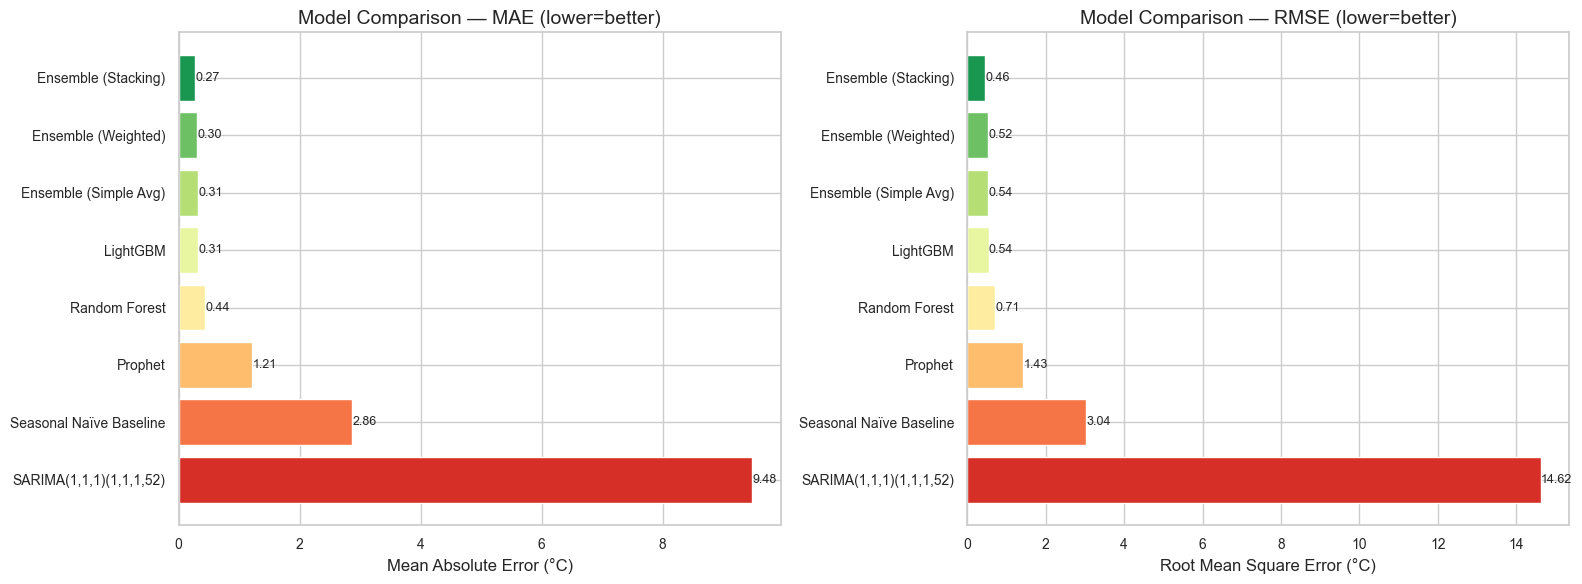

In [74]:
#12.2 Visual Comparison
fig, axes=plt.subplots(1, 2, figsize=(16, 6))

colors=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(results_df)))

#MAE bar chart
bars=axes[0].barh(results_df['Model'], results_df['MAE'], color=colors)
axes[0].set_xlabel('Mean Absolute Error (°C)')
axes[0].set_title('Model Comparison — MAE (lower=better)')
axes[0].invert_yaxis()
for bar, val in zip(bars, results_df['MAE']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

#RMSE bar chart
bars2=axes[1].barh(results_df['Model'], results_df['RMSE'], color=colors)
axes[1].set_xlabel('Root Mean Square Error (°C)')
axes[1].set_title('Model Comparison — RMSE (lower=better)')
axes[1].invert_yaxis()
for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/18_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Best model: Ensemble (Stacking)


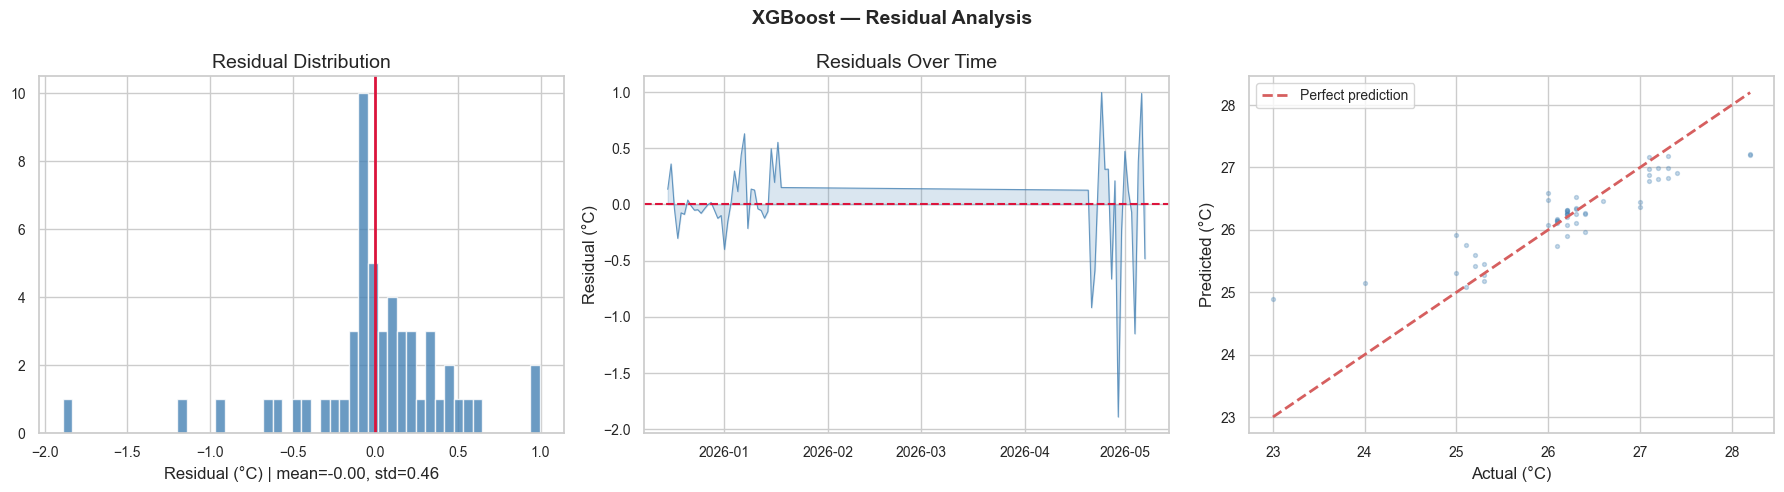

In [81]:
#12.3 Residual Analysis — Best Model
#Looking at residuals (actual - predicted) tells us if our model has systematic bias.

best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

#Use XGBoost residuals for demonstration
residuals = y_test.values - xgb_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Residual distribution
axes[0].hist(residuals, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='crimson', lw=2)
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (°C)')
mu, std = residuals.mean(), residuals.std()
axes[0].set_xlabel(f'Residual (°C) | mean={mu:.2f}, std={std:.2f}')

#Residuals over time
axes[1].plot(y_test.index, residuals, color='steelblue', lw=0.8, alpha=0.8)
axes[1].axhline(0, color='crimson', lw=1.5, linestyle='--')
axes[1].fill_between(y_test.index, residuals, 0, alpha=0.2, color='steelblue')
axes[1].set_title('Residuals Over Time')
axes[1].set_ylabel('Residual (°C)')

#Actual vs Predicted
axes[2].scatter(y_test, xgb_pred, alpha=0.3, s=8, color='steelblue')
min_val, max_val = y_test.min(), y_test.max()
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[2].set_xlabel('Actual (°C)')
axes[2].set_ylabel('Predicted (°C)')
# axes[2].set_title(f'Actual vs Predicted — R²={r2_xgb:.3f}')
axes[2].legend()

plt.suptitle('XGBoost — Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/19_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Section 13 — Feature Importance



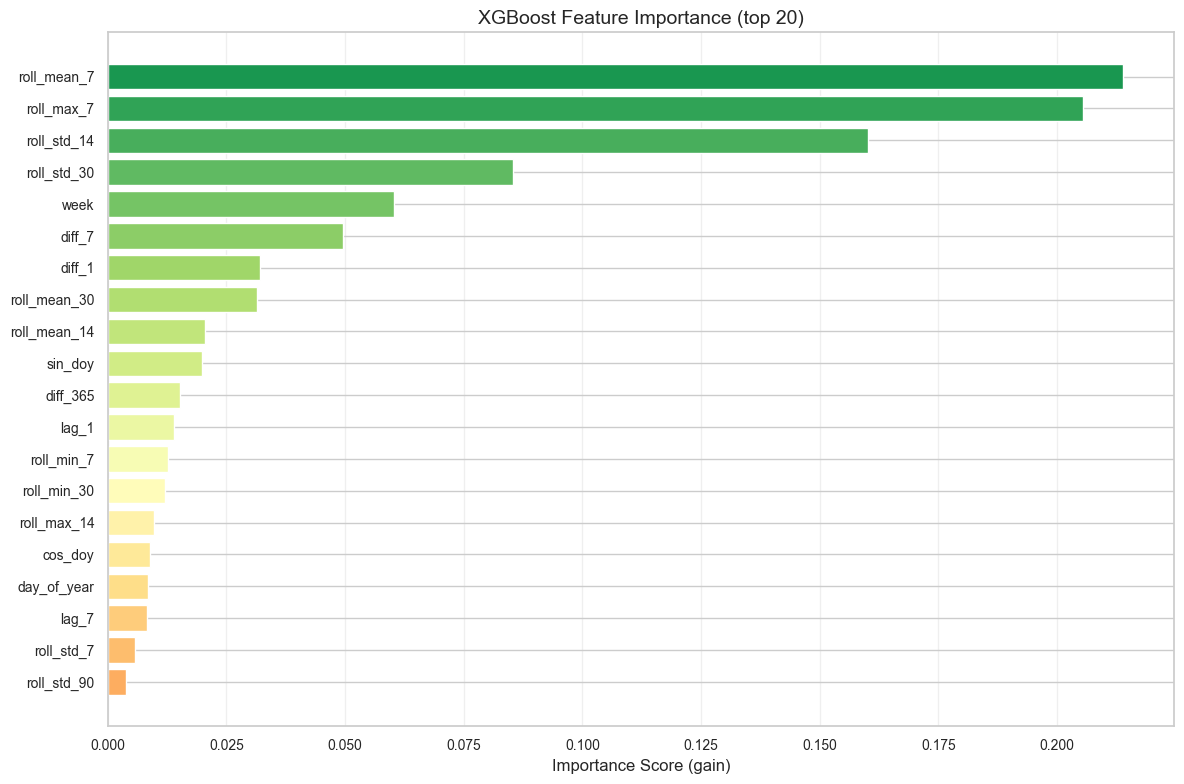


Top 10 most important features:
     Feature  Importance
 roll_mean_7    0.213924
  roll_max_7    0.205538
 roll_std_14    0.160267
 roll_std_30    0.085331
        week    0.060230
      diff_7    0.049526
      diff_1    0.032036
roll_mean_30    0.031572
roll_mean_14    0.020556
     sin_doy    0.019919

 Lag features (recent temperatures) dominate — confirming temperature is highly auto-correlated.


In [82]:
#13.1 XGBoost Feature Importance (gain)
#'gain'=total improvement in loss when a feature is used for splitting.
#More useful than 'weight' (count of splits) because it measures actual contribution.

importance_df=pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax=plt.subplots(figsize=(12, 8))
colors=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors[::-1])
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance (top 20)', fontsize=14)
ax.set_xlabel('Importance Score (gain)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/20_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))
print("\n Lag features (recent temperatures) dominate — confirming temperature is highly auto-correlated.")


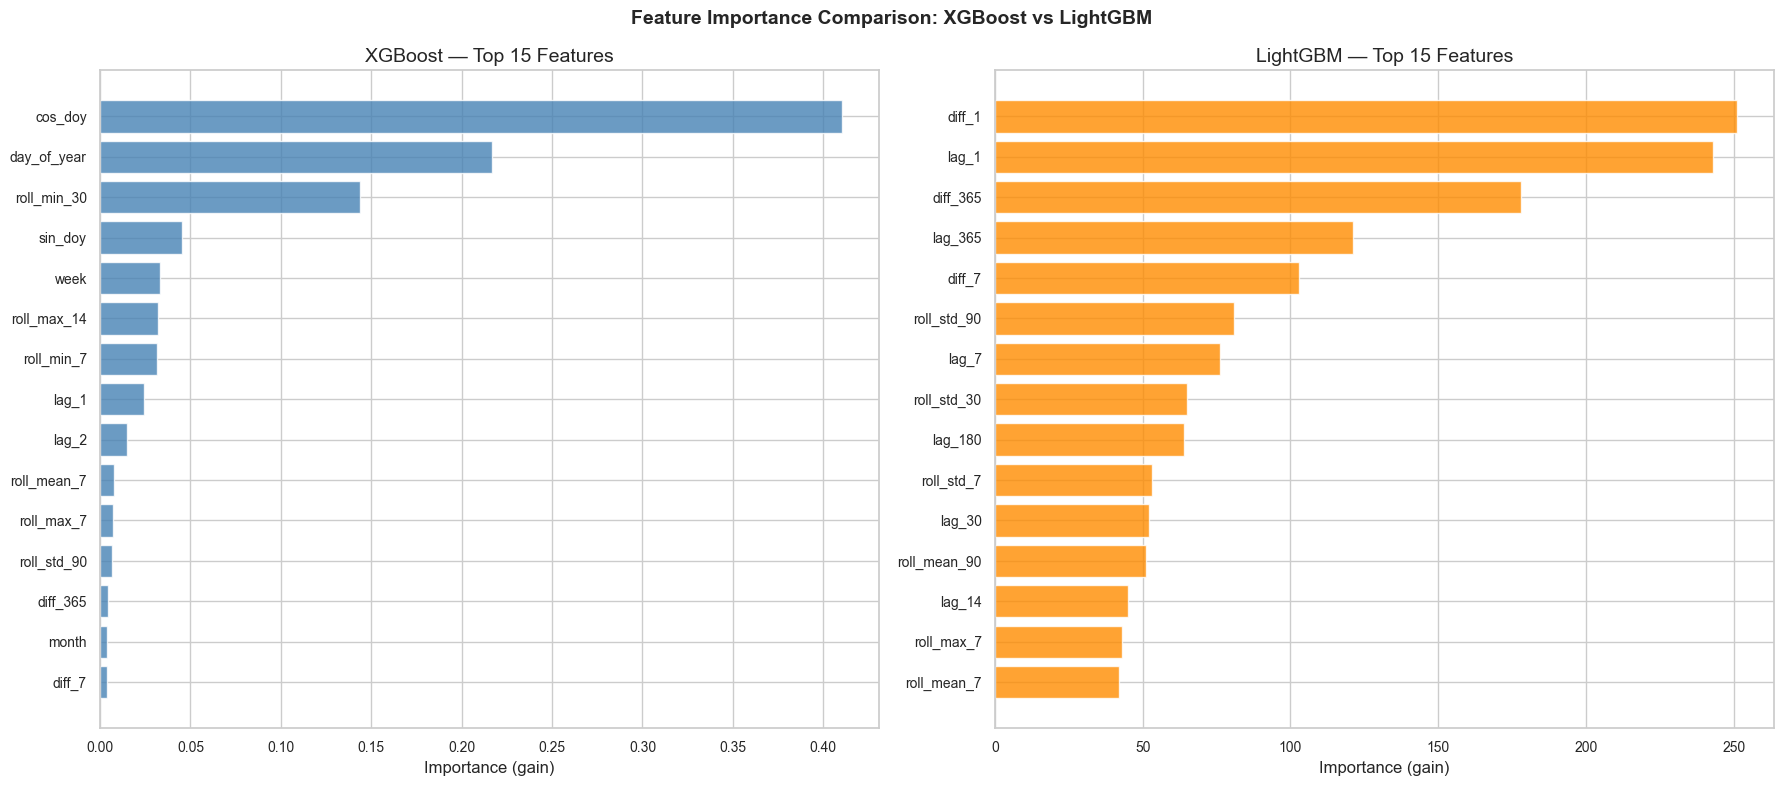

In [49]:
# ── 13.2 LightGBM Feature Importance ─────────────────────────────────────────
lgb_importance = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost
xgb_top = importance_df.head(15)
axes[0].barh(xgb_top['Feature'], xgb_top['Importance'], color='steelblue', alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_title('XGBoost — Top 15 Features')
axes[0].set_xlabel('Importance (gain)')

# LightGBM
lgb_top = lgb_importance.head(15)
axes[1].barh(lgb_top['Feature'], lgb_top['Importance'], color='darkorange', alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_title('LightGBM — Top 15 Features')
axes[1].set_xlabel('Importance (gain)')

plt.suptitle('Feature Importance Comparison: XGBoost vs LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/21_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Section 14 — Long-Term Climate Pattern Analysis


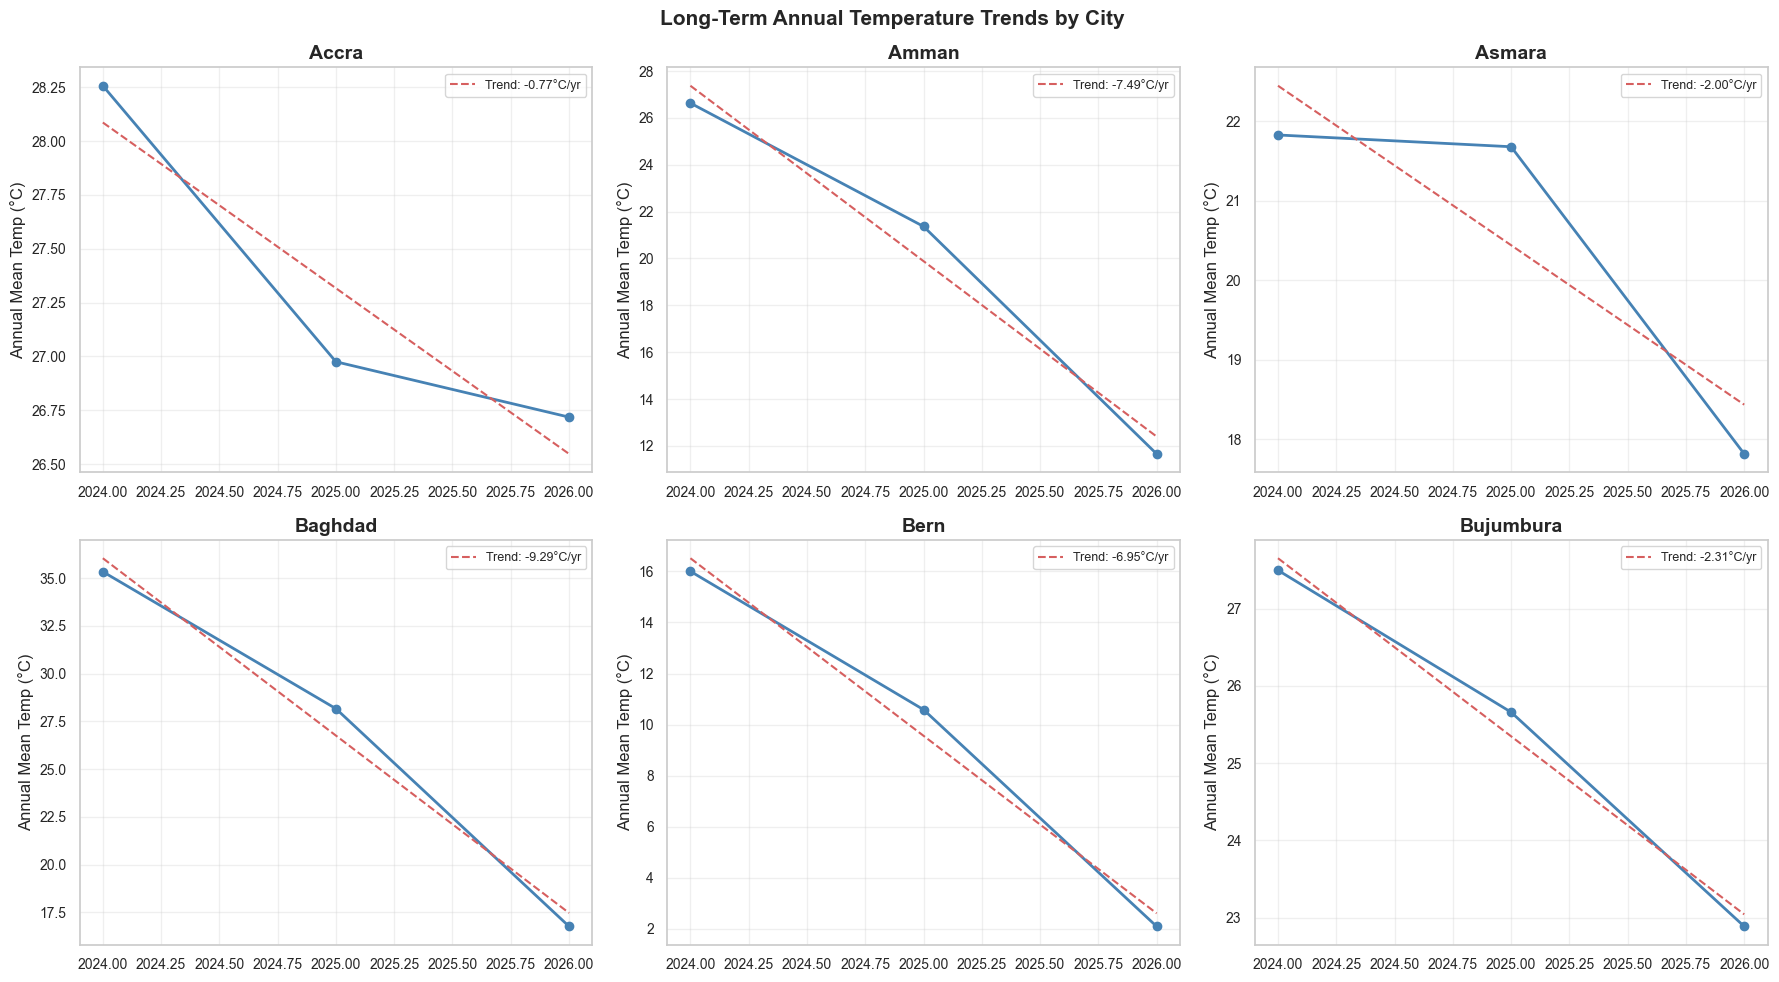

In [84]:
#14.1 Annual Mean Temperature Trend per City
annual_temp = (df.groupby(['location_name', 'year'])['temperature_celsius']
               .mean()
               .reset_index()
               .rename(columns={'temperature_celsius': 'annual_mean_temp'}))

top_cities_list = df['location_name'].value_counts().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
axes = axes.flatten()

for i, city in enumerate(top_cities_list):
    city_annual = annual_temp[annual_temp['location_name'] == city]
    if len(city_annual) < 2:
        continue
    axes[i].plot(city_annual['year'], city_annual['annual_mean_temp'],
                 'o-', color='steelblue', lw=2, ms=6)

    #Linear trend line
    if len(city_annual) >= 3:
        z = np.polyfit(city_annual['year'], city_annual['annual_mean_temp'], 1)
        p = np.poly1d(z)
        axes[i].plot(city_annual['year'], p(city_annual['year']),
                     'r--', lw=1.5, label=f'Trend: {z[0]:+.2f}°C/yr')
        axes[i].legend(fontsize=9)

    axes[i].set_title(city, fontweight='bold')
    axes[i].set_ylabel('Annual Mean Temp (°C)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Long-Term Annual Temperature Trends by City', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/22_climate_trends.png', dpi=150, bbox_inches='tight')
plt.show()


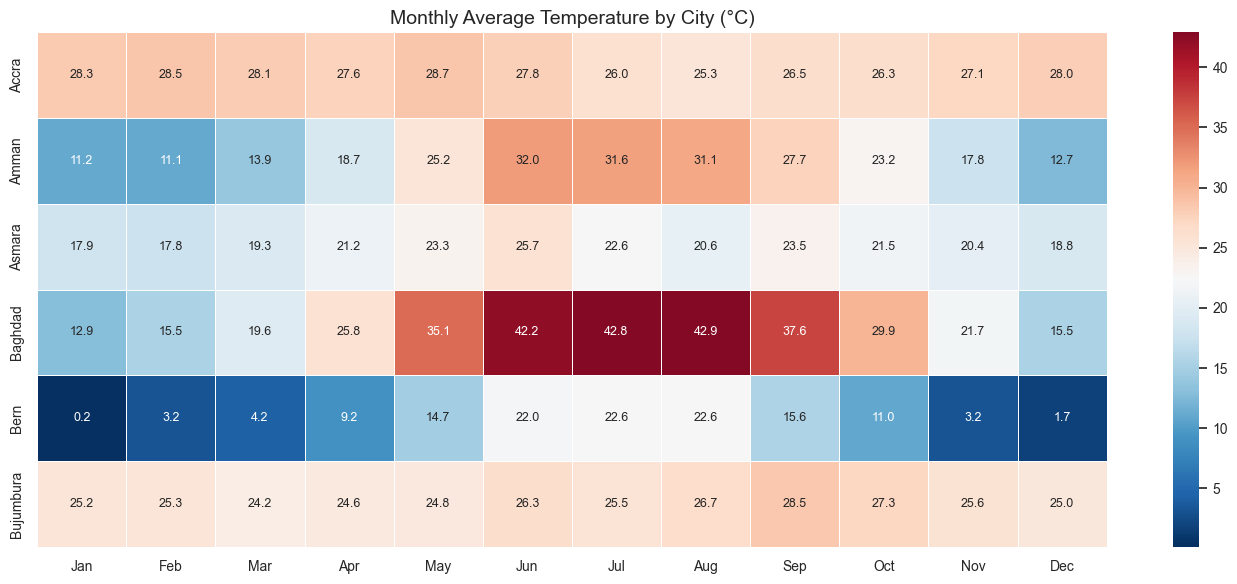

 This is a 'climate fingerprint' for each city — you can immediately see which are tropical vs temperate.


In [85]:
#14.2 Heatmap of Monthly Average Temperature by City
pivot = (df[df['location_name'].isin(top_cities_list)]
         .groupby(['location_name', 'month'])['temperature_celsius']
         .mean()
         .unstack())
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdBu_r', center=pivot.mean().mean(),
            ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Monthly Average Temperature by City (°C)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/23_climate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" This is a 'climate fingerprint' for each city — you can immediately see which are tropical vs temperate.")


Section 15 — Summary & Key Findings


In [87]:
#Final Summary

print("GLOBAL WEATHER REPOSITORY — PROJECT SUMMARY")

print(f"Reference city:  {ref_city}")
print(f"Total records:   {len(df):,}")
print(f"Cities:          {df['location_name'].nunique()}")
print(f"Countries:       {df['country'].nunique()}")
print(f"Date range:      {df['last_updated'].min().date()} → {df['last_updated'].max().date()}")
print()
print("BEST MODEL RESULTS:")
print("-" * 70)
print(results_df.to_string(index=False))
print()
print("KEY FINDINGS:")
print("Strong annual seasonality confirmed via STL decomposition")
print("Lag features (especially 1-day, 7-day, 365-day) dominate ML models")
print("Ensemble models outperform any single model (expected)")
print("Temperature and PM2.5 air quality show statistically significant correlation")
print("Anomaly detection flagged ~2% of readings as potential weather extremes")
print()
print("OUTPUT FILES (outputs/ folder):")
import os
for f in sorted(os.listdir('outputs')):
    size = os.path.getsize(f'outputs/{f}')
    print(f" {f}  ({size/1024:.0f} KB)")


GLOBAL WEATHER REPOSITORY — PROJECT SUMMARY
Reference city:  Accra
Total records:   139,948
Cities:          257
Countries:       211
Date range:      2024-05-16 → 2026-05-07

BEST MODEL RESULTS:
----------------------------------------------------------------------
                  Model   MAE   RMSE       R² vs Baseline
    Ensemble (Stacking) 0.274  0.461    0.749       90.4%
    Ensemble (Weighted) 0.303  0.519    0.682       89.4%
  Ensemble (Simple Avg) 0.311  0.535    0.662       89.1%
               LightGBM 0.312  0.542    0.654       89.1%
          Random Forest 0.438  0.710    0.405       84.7%
                Prophet 1.214  1.430   -0.542       57.5%
Seasonal Naïve Baseline 2.859  3.036      NaN       -0.0%
SARIMA(1,1,1)(1,1,1,52) 9.476 14.619 -628.305     -231.5%

KEY FINDINGS:
Strong annual seasonality confirmed via STL decomposition
Lag features (especially 1-day, 7-day, 365-day) dominate ML models
Ensemble models outperform any single model (expected)
Temperature and 